In [1]:
#declarer le drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 1. Bibliothèques de base & EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# 2. Prétraitement & Encodage
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# 3. Détection d'anomalies
from sklearn.ensemble import IsolationForest

# 4. Modèles de Machine Learning
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 5. Réduction de dimension
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 6. Clustering
from sklearn.cluster import KMeans

# 7. Training & Validation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# 8. Métriques
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, precision_score,
    recall_score, f1_score
)

# 9. Statistiques avancées
from scipy import stats
from scipy.stats import chi2, mode
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

# 10. Requêtes Web / API
import requests

# 11. Fonctions utilitaires – Visualisation
def heatmap_triangle(df, cols, title):
    """
    Affiche une matrice de corrélation de Spearman en heatmap
    uniquement sur le triangle inférieur.
    """
    corr = df[cols].corr(method="spearman")
    mask = np.triu(np.ones_like(corr, dtype=bool))

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        cmap="coolwarm",
        vmin=-1, vmax=1,
        linewidths=0.5
    )
    plt.title(title)
    plt.show()


In [3]:
pip install pycountry


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 34.9 MB/s eta 0:00:00


In [4]:

def to_iso3(country_name):
    try:
        # Essayer de trouver via le nom
        result = pycountry.countries.lookup(country_name)
        return result.alpha_3
    except:
        return None


#  Chargement des données

In [5]:
dali = pd.read_csv("/content/drive/My Drive/Colab Notebooks/P11_OPC/DisponibiliteAlimentaire_2017.csv", sep=",")
display(dali)

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.00,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.00,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.00,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.00,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6701.00,S,Données standardisées
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176595,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,5142,Nourriture,2899,Miscellanees,2017,2017,Milliers de tonnes,19.00,S,Données standardisées
176596,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,645,Disponibilité alimentaire en quantité (kg/pers...,2899,Miscellanees,2017,2017,kg,1.33,Fc,Donnée calculée
176597,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,664,Disponibilité alimentaire (Kcal/personne/jour),2899,Miscellanees,2017,2017,Kcal/personne/jour,1.00,Fc,Donnée calculée
176598,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,674,Disponibilité de protéines en quantité (g/pers...,2899,Miscellanees,2017,2017,g/personne/jour,0.04,Fc,Donnée calculée


Text(0, 0.5, 'somme des valeurs')

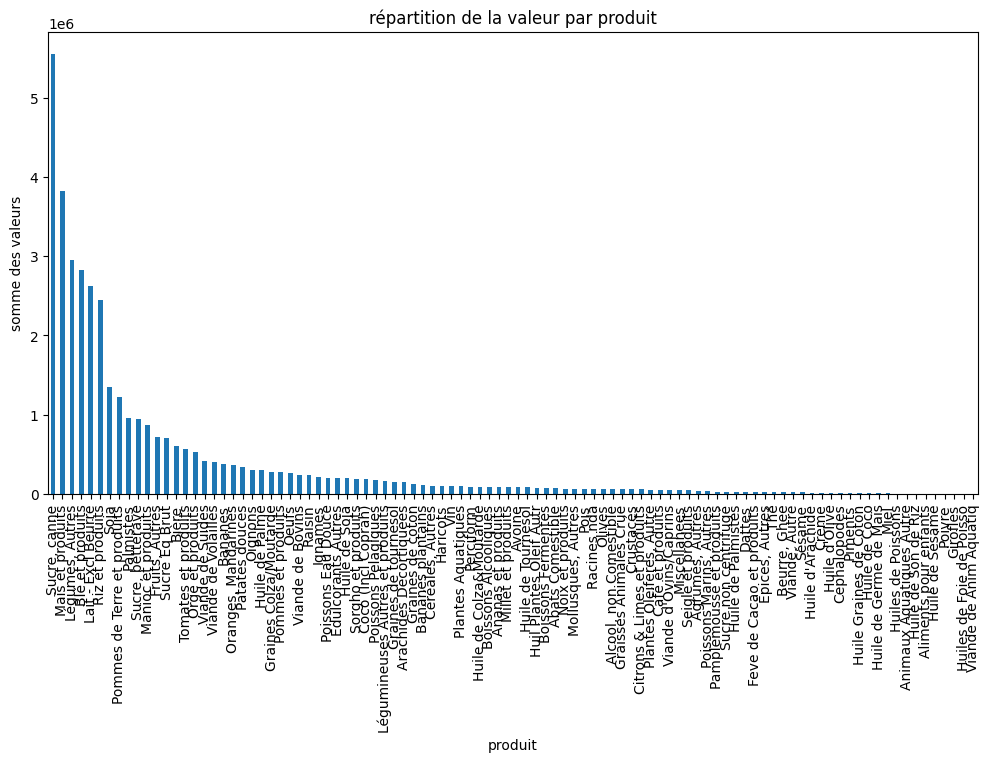

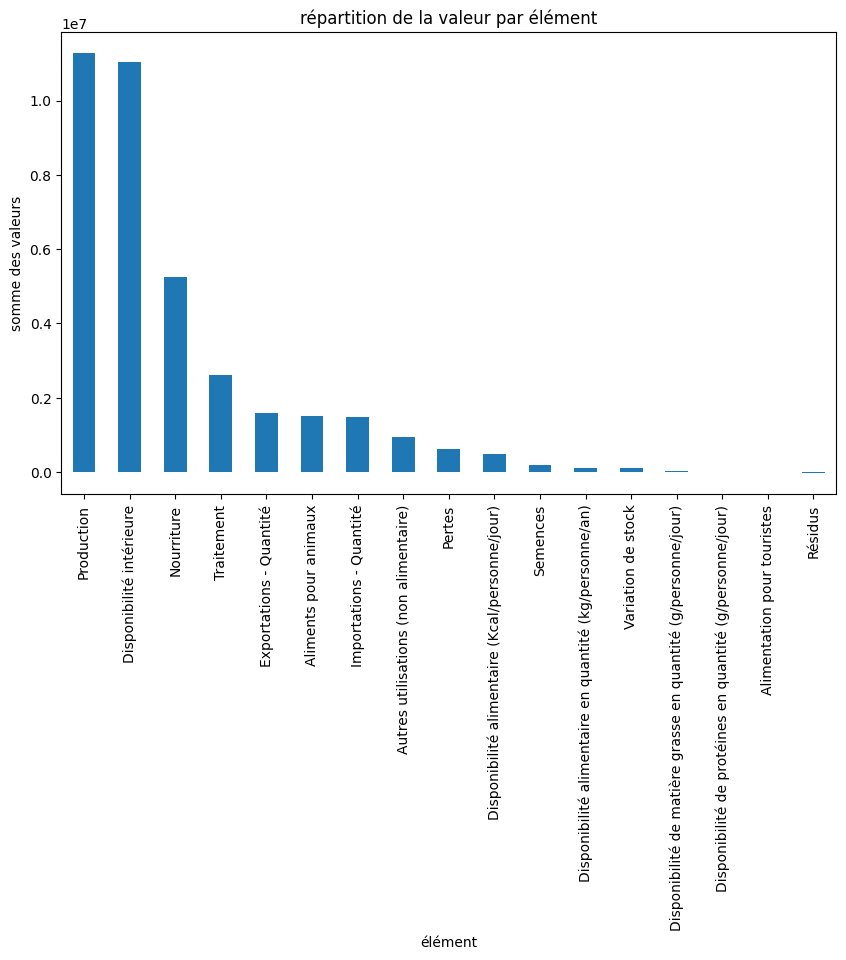

In [6]:


# somme de la valeur par produit
ca_par_produit = dali.groupby("Produit")["Valeur"].sum().sort_values(ascending=False)


# graphique : valeur par produit
plt.figure(figsize=(12,6))
ca_par_produit.plot(kind="bar")
plt.title("répartition de la valeur par produit")
plt.xlabel("produit")
plt.ylabel("somme des valeurs")
#plt.xticks(rotation=90)
#plt.tight_layout()
#plt.show()

# somme de la valeur par élément
ca_par_element = dali.groupby("Élément")["Valeur"].sum().sort_values(ascending=False)

# graphique : valeur par élément
plt.figure(figsize=(10,6))
ca_par_element.plot(kind="bar")
plt.title("répartition de la valeur par élément")
plt.xlabel("élément")
plt.ylabel("somme des valeurs")
#plt.xticks(rotation=45)
#plt.tight_layout()
##plt.show()


In [7]:
dali.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176600 entries, 0 to 176599
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Code Domaine            176600 non-null  object 
 1   Domaine                 176600 non-null  object 
 2   Code zone               176600 non-null  int64  
 3   Zone                    176600 non-null  object 
 4   Code Élément            176600 non-null  int64  
 5   Élément                 176600 non-null  object 
 6   Code Produit            176600 non-null  int64  
 7   Produit                 176600 non-null  object 
 8   Code année              176600 non-null  int64  
 9   Année                   176600 non-null  int64  
 10  Unité                   176600 non-null  object 
 11  Valeur                  176600 non-null  float64
 12  Symbole                 176600 non-null  object 
 13  Description du Symbole  176600 non-null  object 
dtypes: float64(1), int64

In [8]:
pop = pd.read_csv("/content/drive/My Drive/Colab Notebooks/P11_OPC/Population_2000_2018.csv", sep=",")
display(pop)

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN
3,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23680.871,X,Sources internationales sûres,NaN
4,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24726.684,X,Sources internationales sûres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4406,OA,Séries temporelles annuelles,181,Zimbabwe,511,Population totale,3010,Population-Estimations,2014,2014,1000 personnes,13586.707,X,Sources internationales sûres,NaN
4407,OA,Séries temporelles annuelles,181,Zimbabwe,511,Population totale,3010,Population-Estimations,2015,2015,1000 personnes,13814.629,X,Sources internationales sûres,NaN
4408,OA,Séries temporelles annuelles,181,Zimbabwe,511,Population totale,3010,Population-Estimations,2016,2016,1000 personnes,14030.331,X,Sources internationales sûres,NaN
4409,OA,Séries temporelles annuelles,181,Zimbabwe,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,14236.595,X,Sources internationales sûres,NaN


In [9]:
pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4411 entries, 0 to 4410
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            4411 non-null   object 
 1   Domaine                 4411 non-null   object 
 2   Code zone               4411 non-null   int64  
 3   Zone                    4411 non-null   object 
 4   Code Élément            4411 non-null   int64  
 5   Élément                 4411 non-null   object 
 6   Code Produit            4411 non-null   int64  
 7   Produit                 4411 non-null   object 
 8   Code année              4411 non-null   int64  
 9   Année                   4411 non-null   int64  
 10  Unité                   4411 non-null   object 
 11  Valeur                  4411 non-null   float64
 12  Symbole                 4411 non-null   object 
 13  Description du Symbole  4411 non-null   object 
 14  Note                    258 non-null    

# Nettoyage des dfs

## Dali viande

In [10]:
# dali : Viande de Volailles
dali_viande = dali[dali["Produit"] == "Viande de Volailles"]

# afficher le nouveau df
display(dali_viande)


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
651,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2734,Viande de Volailles,2017,2017,Milliers de tonnes,28.00,S,Données standardisées
652,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2734,Viande de Volailles,2017,2017,Milliers de tonnes,29.00,S,Données standardisées
653,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2734,Viande de Volailles,2017,2017,Milliers de tonnes,0.00,S,Données standardisées
654,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2734,Viande de Volailles,2017,2017,Milliers de tonnes,57.00,S,Données standardisées
655,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5123,Pertes,2734,Viande de Volailles,2017,2017,Milliers de tonnes,2.00,S,Données standardisées
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176396,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,5142,Nourriture,2734,Viande de Volailles,2017,2017,Milliers de tonnes,67.00,S,Données standardisées
176397,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,645,Disponibilité alimentaire en quantité (kg/pers...,2734,Viande de Volailles,2017,2017,kg,4.68,Fc,Donnée calculée
176398,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,664,Disponibilité alimentaire (Kcal/personne/jour),2734,Viande de Volailles,2017,2017,Kcal/personne/jour,16.00,Fc,Donnée calculée
176399,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,674,Disponibilité de protéines en quantité (g/pers...,2734,Viande de Volailles,2017,2017,g/personne/jour,1.59,Fc,Donnée calculée


In [11]:
dali_viande_clean = dali_viande.drop(columns=["Symbole","Produit","Code Élément",	"Domaine"	,"Code zone","Description du Symbole", "Code année",	"Année", "Code Domaine", "Code Produit"], axis =1 ).copy()


In [12]:
dali_viande_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2061 entries, 651 to 176400
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Zone     2061 non-null   object 
 1   Élément  2061 non-null   object 
 2   Unité    2061 non-null   object 
 3   Valeur   2061 non-null   float64
dtypes: float64(1), object(3)
memory usage: 80.5+ KB


In [13]:
# verifier les doublons avoir 1 pays par element
# ajouter le code iso car il n'y a que la zone dispo

In [14]:
dali_viande_clean

,Zone,Élément,Unité,Valeur
651,Afghanistan,Production,Milliers de tonnes,28.00
652,Afghanistan,Importations - Quantité,Milliers de tonnes,29.00
653,Afghanistan,Variation de stock,Milliers de tonnes,0.00
654,Afghanistan,Disponibilité intérieure,Milliers de tonnes,57.00
655,Afghanistan,Pertes,Milliers de tonnes,2.00
...,...,...,...,...
176396,Zimbabwe,Nourriture,Milliers de tonnes,67.00
176397,Zimbabwe,Disponibilité alimentaire en quantité (kg/pers...,kg,4.68
176398,Zimbabwe,Disponibilité alimentaire (Kcal/personne/jour),Kcal/personne/jour,16.00
176399,Zimbabwe,Disponibilité de protéines en quantité (g/pers...,g/personne/jour,1.59


## exploration pop

In [15]:
pop.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN
3,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23680.871,X,Sources internationales sûres,NaN
4,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24726.684,X,Sources internationales sûres,NaN


In [16]:
pop_2017 = pop[pop["Année"] == 2017]


In [17]:
pop_2017.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
17,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,36296.113,X,Sources internationales sûres,NaN
36,OA,Séries temporelles annuelles,202,Afrique du Sud,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,57009.756,X,Sources internationales sûres,NaN
55,OA,Séries temporelles annuelles,3,Albanie,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,2884.169,X,Sources internationales sûres,NaN
74,OA,Séries temporelles annuelles,4,Algérie,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,41389.189,X,Sources internationales sûres,NaN
93,OA,Séries temporelles annuelles,79,Allemagne,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,82658.409,X,Sources internationales sûres,NaN


In [18]:
pop_2017 = pop_2017.drop(columns=["Code Élément","Élément","Code Produit","Note","Code zone","Description du Symbole","Code Domaine","Code année","Année", "Symbole"], axis =1 ).copy()


In [19]:
pop_2017.head()

,Domaine,Zone,Produit,Unité,Valeur
17,Séries temporelles annuelles,Afghanistan,Population-Estimations,1000 personnes,36296.113
36,Séries temporelles annuelles,Afrique du Sud,Population-Estimations,1000 personnes,57009.756
55,Séries temporelles annuelles,Albanie,Population-Estimations,1000 personnes,2884.169
74,Séries temporelles annuelles,Algérie,Population-Estimations,1000 personnes,41389.189
93,Séries temporelles annuelles,Allemagne,Population-Estimations,1000 personnes,82658.409


In [20]:
# somme de la valeur par zone
valeur_par_zone = pop.groupby("Zone")["Valeur"].sum().sort_values(ascending=False)



In [21]:
top10_zones = valeur_par_zone.head(10)



In [22]:
flop10_zones = valeur_par_zone.tail(10)




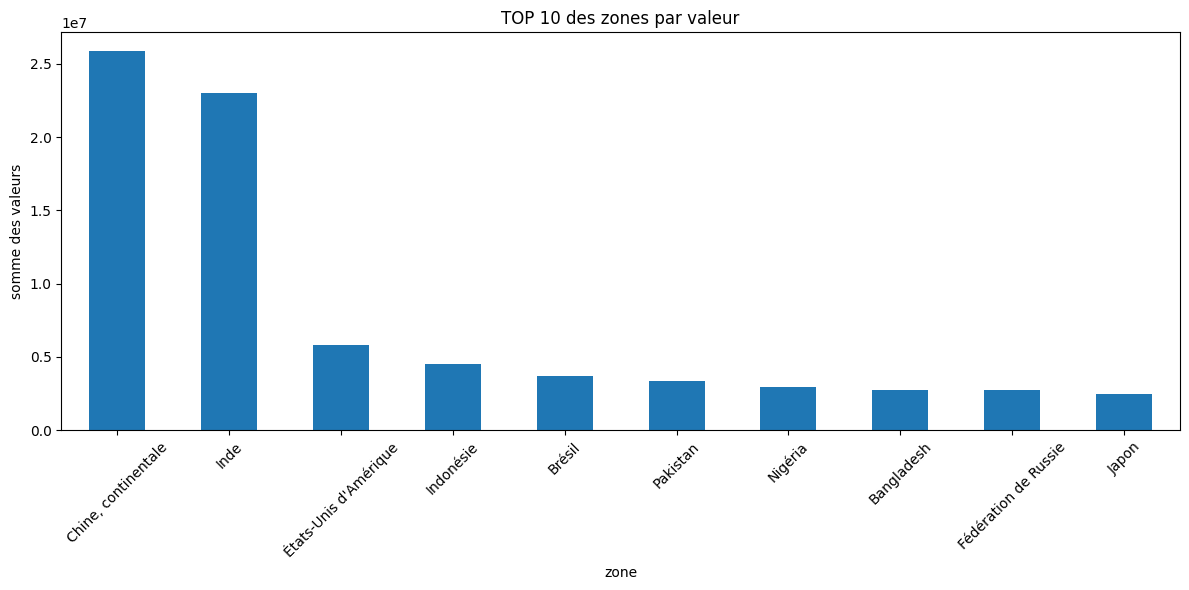

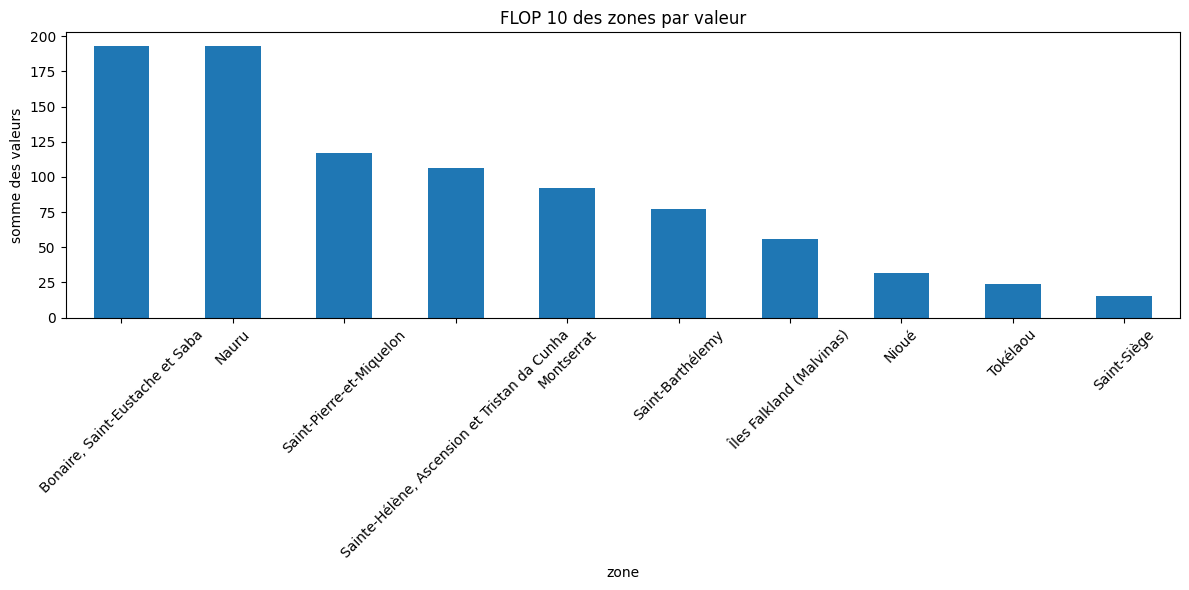

In [23]:

# top 10
plt.figure(figsize=(12,6))
top10_zones.plot(kind="bar")
plt.title("TOP 10 des zones par valeur")
plt.xlabel("zone")
plt.ylabel("somme des valeurs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# flop 10
plt.figure(figsize=(12,6))
flop10_zones.plot(kind="bar")
plt.title("FLOP 10 des zones par valeur")
plt.xlabel("zone")
plt.ylabel("somme des valeurs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## coorelation entre les variables

# Exploration  et Nettoyage des DFS Rajoutes

1-Production de poulet

In [24]:

# url data
url_data = "https://ourworldindata.org/grapher/poultry-production-tonnes.csv?v=1&csvType=full&useColumnShortNames=true"

#df-
prodpoul = pd.read_csv(
    url_data,
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)

# metadata
url_meta = "https://ourworldindata.org/grapher/poultry-production-tonnes.metadata.json?v=1&csvType=full&useColumnShortNames=true"
metadata_prodpoul = requests.get(url_meta).json()

#rename col
prodpoul = prodpoul.rename(columns={
    'Entity': 'country',
    'Code': 'iso3',
    'Year': 'year',
    'meat__poultry__00001808__production__005510__tonnes': 'production_tonnes'
})





In [25]:
prodpoul.columns

Index(['country', 'iso3', 'year', 'production_tonnes'], dtype='object')

In [26]:
print(prodpoul.shape)
prodpoul.head()

(14344, 4)


,country,iso3,year,production_tonnes
0,Afghanistan,AFG,1961,5600.0
1,Afghanistan,AFG,1962,6000.0
2,Afghanistan,AFG,1963,6160.0
3,Afghanistan,AFG,1964,6400.0
4,Afghanistan,AFG,1965,6800.0


In [27]:
prodpoul.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14344 entries, 0 to 14343
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            14344 non-null  object 
 1   iso3               11702 non-null  object 
 2   year               14344 non-null  int64  
 3   production_tonnes  14344 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 448.4+ KB


In [28]:
# filtrer le dataframe pour ne garder que l'année 2027
prodpoul_2017 = prodpoul[prodpoul["year"] == 2017]

# afficher le résultat
display(prodpoul_2017)


,country,iso3,year,production_tonnes
56,Afghanistan,AFG,2017,2.763784e+04
119,Africa,NaN,2017,6.468504e+06
182,Africa (FAO),NaN,2017,6.468504e+06
245,Albania,ALB,2017,1.441411e+04
308,Algeria,DZA,2017,4.000058e+05
...,...,...,...,...
14054,Western Europe (FAO),NaN,2017,5.060576e+06
14117,World,OWID_WRL,2017,1.248002e+08
14180,Yemen,YEM,2017,1.686283e+05
14274,Zambia,ZMB,2017,4.742058e+04


In [29]:
prodpoul_2017 = prodpoul_2017.drop(columns=["year"])


In [30]:
# Vérifier s'il y a des doublons
doublons = prodpoul_2017.duplicated()

# Afficher le nombre de doublons
print("Nombre de doublons :", doublons.sum())

# Si tu veux voir les lignes doublons
display(prodpoul_2017[doublons])

# Vérifier si toutes les lignes sont uniques
if doublons.any():
    print("Il y a des doublons dans le DataFrame.")
else:
    print("Toutes les lignes sont uniques.")


Nombre de doublons : 0


,country,iso3,production_tonnes


Toutes les lignes sont uniques.


2- Consommation de poulet par habitant en  kg/an

In [31]:

# URL DATA OWID
url_cons = "https://ourworldindata.org/grapher/per-capita-meat-type.csv?v=1&csvType=full&useColumnShortNames=true"

# df
conspoul = pd.read_csv(
    url_cons,
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)

# metadata
url_meta_cons = "https://ourworldindata.org/grapher/per-capita-meat-type.metadata.json?v=1&csvType=full&useColumnShortNames=true"
metadata_conspoul = requests.get(url_meta_cons).json()


print(conspoul.columns)



Index(['Entity', 'Code', 'Year',
       'meat__poultry__00002734__food_available_for_consumption__0645pc__kilograms_per_year_per_capita',
       'meat__beef_and_buffalo__00002731__food_available_for_consumption__0645pc__kilograms_per_year_per_capita',
       'meat__sheep_and_goat__00002732__food_available_for_consumption__0645pc__kilograms_per_year_per_capita',
       'meat__pig__00002733__food_available_for_consumption__0645pc__kilograms_per_year_per_capita',
       'meat__other__00002735__food_available_for_consumption__0645pc__kilograms_per_year_per_capita',
       'fish_and_seafood__00002960__food_available_for_consumption__0645pc__kilograms_per_year_per_capita'],
      dtype='object')


In [32]:
conspoul = conspoul.rename(columns={
    "Entity": "pays",
    "Code": "code_pays",
    "meat__poultry__00002734__food_available_for_consumption__0645pc__kilograms_per_year_per_capita": "viande_volaille",
    "meat__beef_and_buffalo__00002731__food_available_for_consumption__0645pc__kilograms_per_year_per_capita": "viande_boeuf_buffalo",
    "meat__sheep_and_goat__00002732__food_available_for_consumption__0645pc__kilograms_per_year_per_capita": "viande_mouton_chevre",
    "meat__pig__00002733__food_available_for_consumption__0645pc__kilograms_per_year_per_capita": "viande_porc",
    "meat__other__00002735__food_available_for_consumption__0645pc__kilograms_per_year_per_capita": "viande_autres",
    "fish_and_seafood__00002960__food_available_for_consumption__0645pc__kilograms_per_year_per_capita": "poisson_fruits_mer"
})


In [33]:
conspoul.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12817 entries, 0 to 12816
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pays                  12817 non-null  object 
 1   code_pays             10216 non-null  object 
 2   Year                  12817 non-null  int64  
 3   viande_volaille       12817 non-null  float64
 4   viande_boeuf_buffalo  12816 non-null  float64
 5   viande_mouton_chevre  12817 non-null  float64
 6   viande_porc           12524 non-null  float64
 7   viande_autres         12814 non-null  float64
 8   poisson_fruits_mer    12816 non-null  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 901.3+ KB


In [34]:
conspoul

,pays,code_pays,Year,viande_volaille,viande_boeuf_buffalo,viande_mouton_chevre,viande_porc,viande_autres,poisson_fruits_mer
0,Afghanistan,AFG,1961,0.612217,4.664513,7.949107,NaN,0.826007,0.029153
1,Afghanistan,AFG,1962,0.641584,4.870207,7.699009,NaN,0.855445,0.029163
2,Afghanistan,AFG,1963,0.641825,4.920656,7.867216,NaN,1.040534,0.029174
3,Afghanistan,AFG,1964,0.651751,4.892996,8.122567,NaN,0.982490,0.029183
4,Afghanistan,AFG,1965,0.681098,4.855254,8.406693,NaN,1.031377,0.029190
...,...,...,...,...,...,...,...,...,...
12812,Zimbabwe,ZWE,2018,4.385163,41.038322,1.822145,0.520613,2.472912,4.164904
12813,Zimbabwe,ZWE,2019,4.494362,41.203354,1.779647,0.693761,2.463353,3.197332
12814,Zimbabwe,ZWE,2020,7.276302,40.488937,1.776185,0.645885,2.371610,3.501910
12815,Zimbabwe,ZWE,2021,7.421084,44.313896,1.974231,0.739071,2.379201,2.723427


In [35]:
# filtrer le dataframe pour ne garder que l'année 2017
conspoul_2017 = conspoul[conspoul["Year"] == 2017]
display(conspoul_2017)


,pays,code_pays,Year,viande_volaille,viande_boeuf_buffalo,viande_mouton_chevre,viande_porc,viande_autres,poisson_fruits_mer
56,Afghanistan,AFG,2017,1.787717,2.916276,4.444324,0.019974,0.329579,0.429452
118,Africa,NaN,2017,6.213189,5.771749,2.400592,1.385660,1.560915,9.718818
180,Africa (FAO),NaN,2017,6.310000,5.870000,2.440000,1.400000,1.590000,9.880000
242,Albania,ALB,2017,11.474741,13.789558,9.060575,8.206179,0.228501,8.692986
304,Algeria,DZA,2017,6.857851,5.002778,7.854460,0.000000,0.355227,4.154180
...,...,...,...,...,...,...,...,...,...
12532,Western Europe (FAO),NaN,2017,20.020000,17.850000,1.610000,38.230000,2.050000,21.910000
12594,World,OWID_WRL,2017,15.241873,8.807075,1.947243,15.172682,0.840181,19.996310
12656,Yemen,YEM,2017,7.633187,1.933257,3.539766,0.000000,0.081687,3.049644
12749,Zambia,ZMB,2017,3.461330,11.514626,0.624825,1.676117,2.291024,12.754357


###  repartition des autres produits et suppression des colonnes

In [36]:
conspoul_2017.columns

Index(['pays', 'code_pays', 'Year', 'viande_volaille', 'viande_boeuf_buffalo',
       'viande_mouton_chevre', 'viande_porc', 'viande_autres',
       'poisson_fruits_mer'],
      dtype='object')

In [37]:
conspoul_2017 = conspoul_2017.drop(columns=["viande_boeuf_buffalo",	"viande_mouton_chevre",	"viande_porc"	,"viande_autres",	"poisson_fruits_mer"])


In [38]:
conspoul_2017.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222 entries, 56 to 12811
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pays             222 non-null    object 
 1   code_pays        181 non-null    object 
 2   Year             222 non-null    int64  
 3   viande_volaille  222 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 8.7+ KB


3- PIB par habitant


In [39]:
pib_pys = pd.read_excel('/content/drive/My Drive/Colab Notebooks/P11_OPC/pib_par_pays.xlsx')#,sep=';')
pib_pys.columns
display(pib_pys)

,Series Name,Series Code,Country Name,Country Code,1990 [YR1990],2000 [YR2000],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,GDP per capita (current US$),NY.GDP.PCAP.CD,Afghanistan,AFG,..,174.930991,565.56973,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,..
1,GDP per capita (current US$),NY.GDP.PCAP.CD,Albania,ALB,617.230436,1160.420471,3981.726623,4168.375445,4614.047969,5365.488802,5460.430509,5370.7775,6413.282808,6846.426694,8575.171346,10011.627986
2,GDP per capita (current US$),NY.GDP.PCAP.CD,Algeria,DZA,2445.183327,1772.928691,4685.059027,4424.98529,4554.66754,4577.210292,4468.453419,3743.541952,4160.559267,4961.552577,5364.02795,5631.179991
3,GDP per capita (current US$),NY.GDP.PCAP.CD,American Samoa,ASM,..,..,12727.410265,12843.33429,11863.683945,12552.054687,12886.135952,14489.258656,15236.160488,18017.458938,..,..
4,GDP per capita (current US$),NY.GDP.PCAP.CD,Andorra,AND,19563.657472,21810.248743,38654.93472,40129.819201,40672.994335,42819.77458,41257.804585,37361.090067,42425.699676,42414.059009,46812.448449,49303.67339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
269,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
pib_pys.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271 entries, 0 to 270
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Series Name    268 non-null    object
 1   Series Code    266 non-null    object
 2   Country Name   266 non-null    object
 3   Country Code   266 non-null    object
 4   1990 [YR1990]  266 non-null    object
 5   2000 [YR2000]  266 non-null    object
 6   2015 [YR2015]  266 non-null    object
 7   2016 [YR2016]  266 non-null    object
 8   2017 [YR2017]  266 non-null    object
 9   2018 [YR2018]  266 non-null    object
 10  2019 [YR2019]  266 non-null    object
 11  2020 [YR2020]  266 non-null    object
 12  2021 [YR2021]  266 non-null    object
 13  2022 [YR2022]  266 non-null    object
 14  2023 [YR2023]  266 non-null    object
 15  2024 [YR2024]  266 non-null    object
dtypes: object(16)
memory usage: 34.0+ KB


In [41]:
pib_pys.columns

Index(['Series Name', 'Series Code', 'Country Name', 'Country Code',
       '1990 [YR1990]', '2000 [YR2000]', '2015 [YR2015]', '2016 [YR2016]',
       '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]',
       '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]'],
      dtype='object')

In [42]:

# sélectionner uniquement les colonnes utiles pour 2017
pib_pys_2017 = pib_pys[["Series Name", "Series Code", "Country Name", "Country Code", "2017 [YR2017]"]]

# renommer la colonne année pour plus de clarté
pib_pys_2017 = pib_pys_2017.rename(columns={"2017 [YR2017]": "Valeur"})

# afficher le résultat
display(pib_pys_2017)


,Series Name,Series Code,Country Name,Country Code,Valeur
0,GDP per capita (current US$),NY.GDP.PCAP.CD,Afghanistan,AFG,525.469771
1,GDP per capita (current US$),NY.GDP.PCAP.CD,Albania,ALB,4614.047969
2,GDP per capita (current US$),NY.GDP.PCAP.CD,Algeria,DZA,4554.66754
3,GDP per capita (current US$),NY.GDP.PCAP.CD,American Samoa,ASM,11863.683945
4,GDP per capita (current US$),NY.GDP.PCAP.CD,Andorra,AND,40672.994335
...,...,...,...,...,...
266,NaN,NaN,NaN,NaN,NaN
267,NaN,NaN,NaN,NaN,NaN
268,NaN,NaN,NaN,NaN,NaN
269,Data from database: World Development Indicators,NaN,NaN,NaN,NaN


In [43]:
pib_pys_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271 entries, 0 to 270
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Series Name   268 non-null    object
 1   Series Code   266 non-null    object
 2   Country Name  266 non-null    object
 3   Country Code  266 non-null    object
 4   Valeur        266 non-null    object
dtypes: object(5)
memory usage: 10.7+ KB


In [44]:
# convertir la colonne 'Valeur' en numérique
pib_pys_2017["Valeur"] = pd.to_numeric(pib_pys_2017["Valeur"], errors="coerce")

# supprimer les lignes où 'Valeur' est NaN si nécessaire
pib_pys_2017 = pib_pys_2017.dropna(subset=["Valeur"])

# vérifier le résultat
pib_pys_2017.info()
display(pib_pys_2017.head())


<class 'pandas.core.frame.DataFrame'>
Index: 258 entries, 0 to 265
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Series Name   258 non-null    object 
 1   Series Code   258 non-null    object 
 2   Country Name  258 non-null    object 
 3   Country Code  258 non-null    object 
 4   Valeur        258 non-null    float64
dtypes: float64(1), object(4)
memory usage: 12.1+ KB


,Series Name,Series Code,Country Name,Country Code,Valeur
0,GDP per capita (current US$),NY.GDP.PCAP.CD,Afghanistan,AFG,525.469771
1,GDP per capita (current US$),NY.GDP.PCAP.CD,Albania,ALB,4614.047969
2,GDP per capita (current US$),NY.GDP.PCAP.CD,Algeria,DZA,4554.667540
3,GDP per capita (current US$),NY.GDP.PCAP.CD,American Samoa,ASM,11863.683945
4,GDP per capita (current US$),NY.GDP.PCAP.CD,Andorra,AND,40672.994335


In [45]:
# supprimer les colonnes Series Name et Series Code
pib_pys_2017 = pib_pys_2017.drop(columns=["Series Name", "Series Code"])
pib_pys_2017.info()
display(pib_pys_2017.head())


<class 'pandas.core.frame.DataFrame'>
Index: 258 entries, 0 to 265
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  258 non-null    object 
 1   Country Code  258 non-null    object 
 2   Valeur        258 non-null    float64
dtypes: float64(1), object(2)
memory usage: 8.1+ KB


,Country Name,Country Code,Valeur
0,Afghanistan,AFG,525.469771
1,Albania,ALB,4614.047969
2,Algeria,DZA,4554.667540
3,American Samoa,ASM,11863.683945
4,Andorra,AND,40672.994335


4- Index de Stabilité Politique

In [46]:
stab_pol = pd.read_excel('/content/drive/My Drive/Colab Notebooks/P11_OPC/Worldwide Governance Indicators 2012-2022.xlsx')
stab_pol.columns
display(stab_pol)

,Country,ISO3,ID Data,Year,Voice and Accountability,Political Stability,Government Effectiveness,Regulatory Quality,Rule of Law,Control of Corruption,Region
0,Afghanistan,AFG,1,2012,14.084507,1.895735,5.687204,10.426540,1.408451,1.421801,Middle East & North Africa (MENA)
1,Afghanistan,AFG,1,2013,14.553990,1.421801,5.687204,10.426540,1.877934,0.947867,Middle East & North Africa (MENA)
2,Afghanistan,AFG,1,2014,16.256157,2.857143,7.211538,11.057693,4.326923,5.288462,Middle East & North Africa (MENA)
3,Afghanistan,AFG,1,2015,18.719212,0.952381,7.211538,14.903846,4.326923,5.769231,Middle East & North Africa (MENA)
4,Afghanistan,AFG,1,2016,20.689655,0.952381,8.173077,7.211538,5.769231,3.846154,Middle East & North Africa (MENA)
...,...,...,...,...,...,...,...,...,...,...,...
1975,Zimbabwe,ZWE,180,2018,16.908213,20.283018,9.134615,5.288462,8.173077,10.096154,Sub-Saharan Africa (SSA)
1976,Zimbabwe,ZWE,180,2019,16.425121,14.622642,10.096154,6.250000,7.211538,10.096154,Sub-Saharan Africa (SSA)
1977,Zimbabwe,ZWE,180,2020,17.874395,13.207547,9.134615,7.692307,7.692307,9.615385,Sub-Saharan Africa (SSA)
1978,Zimbabwe,ZWE,180,2021,18.357489,14.150944,11.057693,7.211538,8.653846,8.653846,Sub-Saharan Africa (SSA)


In [47]:
stab_pol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   1980 non-null   object 
 1   ISO3                      1980 non-null   object 
 2   ID Data                   1980 non-null   int64  
 3   Year                      1980 non-null   int64  
 4   Voice and Accountability  1980 non-null   float64
 5   Political Stability       1980 non-null   float64
 6   Government Effectiveness  1980 non-null   float64
 7   Regulatory Quality        1980 non-null   float64
 8   Rule of Law               1980 non-null   float64
 9   Control of Corruption     1980 non-null   float64
 10  Region                    1980 non-null   object 
dtypes: float64(6), int64(2), object(3)
memory usage: 170.3+ KB


In [48]:
# filtrer le dataframe pour ne garder que l'année 2017
stab_pol_2017 = stab_pol[stab_pol["Year"] == 2017]

# afficher le résultat
display(stab_pol_2017)


,Country,ISO3,ID Data,Year,Voice and Accountability,Political Stability,Government Effectiveness,Regulatory Quality,Rule of Law,Control of Corruption,Region
5,Afghanistan,AFG,1,2017,22.167488,0.476190,8.173077,7.211538,5.288462,3.846154,Middle East & North Africa (MENA)
16,Albania,ALB,2,2017,54.187191,59.523811,58.653847,62.500000,39.423077,41.826923,Europe & Central Asia (ECA)
27,United Arab Emirates,ARE,3,2017,18.226601,66.666664,90.384613,80.769234,77.403847,82.692307,Middle East & North Africa (MENA)
38,Angola,AGO,4,2017,17.733990,30.476191,17.788462,13.461538,14.903846,5.769231,Sub-Saharan Africa (SSA)
49,Argentina,ARG,5,2017,64.532021,53.333332,59.134617,44.711540,46.634617,45.673077,Latin America & Carribean (LAC)
...,...,...,...,...,...,...,...,...,...,...,...
1930,Venezuela,VEN,176,2017,14.285714,10.000000,7.211538,2.403846,0.480769,6.730769,Latin America & Carribean (LAC)
1941,Vietnam,VNM,177,2017,10.344828,54.761906,53.846153,35.576923,55.288460,31.250000,East Asia & Pacific (EAP)
1952,Syria,SYR,178,2017,1.970443,0.952381,2.884615,3.365385,0.961538,2.403846,Middle East & North Africa (MENA)
1963,Zambia,ZMB,179,2017,36.453201,52.380951,25.961538,33.173077,41.346153,35.096153,Sub-Saharan Africa (SSA)


In [49]:
stab_pol_2017.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 5 to 1974
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   180 non-null    object 
 1   ISO3                      180 non-null    object 
 2   ID Data                   180 non-null    int64  
 3   Year                      180 non-null    int64  
 4   Voice and Accountability  180 non-null    float64
 5   Political Stability       180 non-null    float64
 6   Government Effectiveness  180 non-null    float64
 7   Regulatory Quality        180 non-null    float64
 8   Rule of Law               180 non-null    float64
 9   Control of Corruption     180 non-null    float64
 10  Region                    180 non-null    object 
dtypes: float64(6), int64(2), object(3)
memory usage: 16.9+ KB


In [50]:
stab_pol_2017

,Country,ISO3,ID Data,Year,Voice and Accountability,Political Stability,Government Effectiveness,Regulatory Quality,Rule of Law,Control of Corruption,Region
5,Afghanistan,AFG,1,2017,22.167488,0.476190,8.173077,7.211538,5.288462,3.846154,Middle East & North Africa (MENA)
16,Albania,ALB,2,2017,54.187191,59.523811,58.653847,62.500000,39.423077,41.826923,Europe & Central Asia (ECA)
27,United Arab Emirates,ARE,3,2017,18.226601,66.666664,90.384613,80.769234,77.403847,82.692307,Middle East & North Africa (MENA)
38,Angola,AGO,4,2017,17.733990,30.476191,17.788462,13.461538,14.903846,5.769231,Sub-Saharan Africa (SSA)
49,Argentina,ARG,5,2017,64.532021,53.333332,59.134617,44.711540,46.634617,45.673077,Latin America & Carribean (LAC)
...,...,...,...,...,...,...,...,...,...,...,...
1930,Venezuela,VEN,176,2017,14.285714,10.000000,7.211538,2.403846,0.480769,6.730769,Latin America & Carribean (LAC)
1941,Vietnam,VNM,177,2017,10.344828,54.761906,53.846153,35.576923,55.288460,31.250000,East Asia & Pacific (EAP)
1952,Syria,SYR,178,2017,1.970443,0.952381,2.884615,3.365385,0.961538,2.403846,Middle East & North Africa (MENA)
1963,Zambia,ZMB,179,2017,36.453201,52.380951,25.961538,33.173077,41.346153,35.096153,Sub-Saharan Africa (SSA)


In [51]:
#tous les dfs
"""
dali_viande
pop_viande
prodpoul_2017
conspoul_2017
pib_pys_2017
stab_pol_2017
"""

'\ndali_viande\npop_viande\nprodpoul_2017\nconspoul_2017\npib_pys_2017\nstab_pol_2017\n'

In [52]:
dali_viande.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2061 entries, 651 to 176400
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            2061 non-null   object 
 1   Domaine                 2061 non-null   object 
 2   Code zone               2061 non-null   int64  
 3   Zone                    2061 non-null   object 
 4   Code Élément            2061 non-null   int64  
 5   Élément                 2061 non-null   object 
 6   Code Produit            2061 non-null   int64  
 7   Produit                 2061 non-null   object 
 8   Code année              2061 non-null   int64  
 9   Année                   2061 non-null   int64  
 10  Unité                   2061 non-null   object 
 11  Valeur                  2061 non-null   float64
 12  Symbole                 2061 non-null   object 
 13  Description du Symbole  2061 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory

In [53]:
dali_viande_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2061 entries, 651 to 176400
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Zone     2061 non-null   object 
 1   Élément  2061 non-null   object 
 2   Unité    2061 non-null   object 
 3   Valeur   2061 non-null   float64
dtypes: float64(1), object(3)
memory usage: 80.5+ KB


In [54]:
prodpoul_2017.info()


<class 'pandas.core.frame.DataFrame'>
Index: 239 entries, 56 to 14337
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            239 non-null    object 
 1   iso3               198 non-null    object 
 2   production_tonnes  239 non-null    float64
dtypes: float64(1), object(2)
memory usage: 7.5+ KB


In [55]:
conspoul_2017.info()


<class 'pandas.core.frame.DataFrame'>
Index: 222 entries, 56 to 12811
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pays             222 non-null    object 
 1   code_pays        181 non-null    object 
 2   Year             222 non-null    int64  
 3   viande_volaille  222 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 8.7+ KB


In [56]:
pib_pys_2017.info()


<class 'pandas.core.frame.DataFrame'>
Index: 258 entries, 0 to 265
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  258 non-null    object 
 1   Country Code  258 non-null    object 
 2   Valeur        258 non-null    float64
dtypes: float64(1), object(2)
memory usage: 8.1+ KB


In [57]:
stab_pol_2017.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 5 to 1974
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   180 non-null    object 
 1   ISO3                      180 non-null    object 
 2   ID Data                   180 non-null    int64  
 3   Year                      180 non-null    int64  
 4   Voice and Accountability  180 non-null    float64
 5   Political Stability       180 non-null    float64
 6   Government Effectiveness  180 non-null    float64
 7   Regulatory Quality        180 non-null    float64
 8   Rule of Law               180 non-null    float64
 9   Control of Corruption     180 non-null    float64
 10  Region                    180 non-null    object 
dtypes: float64(6), int64(2), object(3)
memory usage: 16.9+ KB


In [58]:
pib_pys_2017

,Country Name,Country Code,Valeur
0,Afghanistan,AFG,525.469771
1,Albania,ALB,4614.047969
2,Algeria,DZA,4554.667540
3,American Samoa,ASM,11863.683945
4,Andorra,AND,40672.994335
...,...,...,...
261,Sub-Saharan Africa,SSF,1542.244649
262,Sub-Saharan Africa (excluding high income),SSA,1630.625959
263,Sub-Saharan Africa (IDA & IBRD countries),TSS,1542.244649
264,Upper middle income,UMC,8053.633182


# ANALYSES UNIVARIEE ET BIVARIEE DES DFS RAJOUTES

In [59]:

def explore_df(df, nom_df, valeur_col=None, zone_col=None):
    """
    df : dataframe à explorer
    nom_df : nom pour titre des graphiques
    valeur_col : colonne quantitative pour top/flop 5
    zone_col : colonne à utiliser pour classement (ex: pays ou region)
    """
    print(f"### exploration de {nom_df} ###\n")

    # 1️stat descriptives
    print("statistiques descriptives :")
    display(df.describe(include='all'))

    # 2️ heatmap de corrélation (triangle inférieur)
    numeric_df = df.select_dtypes(include=np.number)
    if not numeric_df.empty:
        corr = numeric_df.corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))
        plt.figure(figsize=(8,6))
        sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", linewidths=0.5)
        plt.title(f"corrélation des variables - {nom_df}")
        plt.show()


In [60]:
def top_flop(df, nom_df, valeur_col, zone_col):
    """
    Affiche top 5 et flop 5 d'une variable quantitative par zone/pays
    """
    agg = df.groupby(zone_col)[valeur_col].sum().sort_values(ascending=False)

    top5 = agg.head(5)
    flop5 = agg.tail(5)

    # top 5
    plt.figure(figsize=(8,4))
    top5.plot(kind="bar", color="green")
    plt.title(f"top 5 {valeur_col} par {zone_col} - {nom_df}")
    plt.ylabel(valeur_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # flop 5
    plt.figure(figsize=(8,4))
    flop5.plot(kind="bar", color="red")
    plt.title(f"flop 5 {valeur_col} par {zone_col} - {nom_df}")
    plt.ylabel(valeur_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### exploration de prodpoul_2017 ###

statistiques descriptives :


,country,iso3,production_tonnes
count,239,198,2.390000e+02
unique,239,198,NaN
top,Afghanistan,AFG,NaN
freq,1,1,NaN
mean,NaN,NaN,3.339886e+06
std,NaN,NaN,1.155976e+07
min,NaN,NaN,4.030000e+00
25%,NaN,NaN,1.426156e+04
50%,NaN,NaN,1.043620e+05
75%,NaN,NaN,1.295497e+06


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


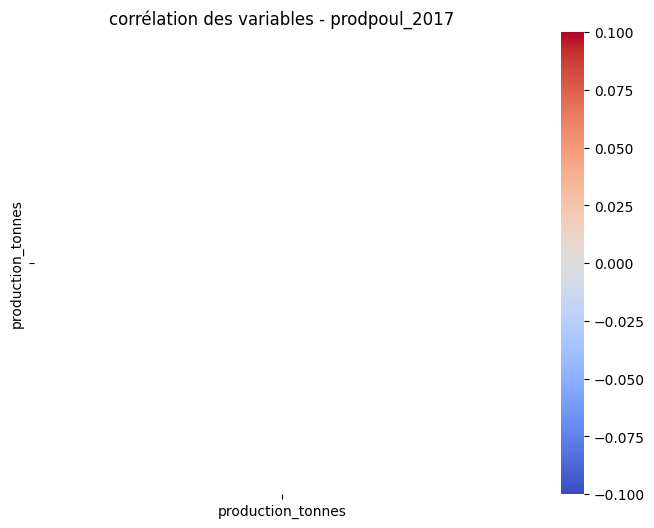

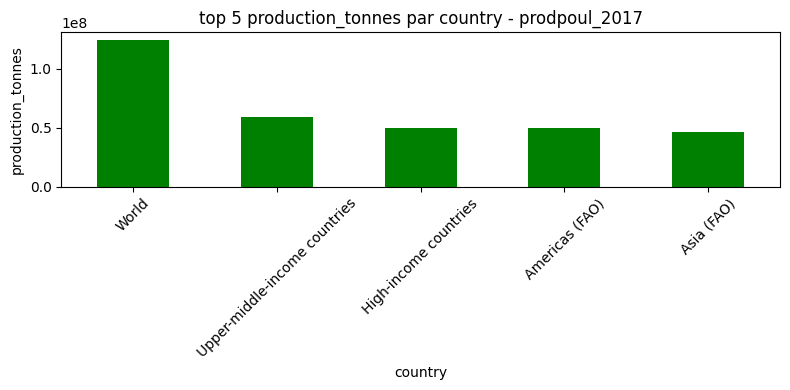

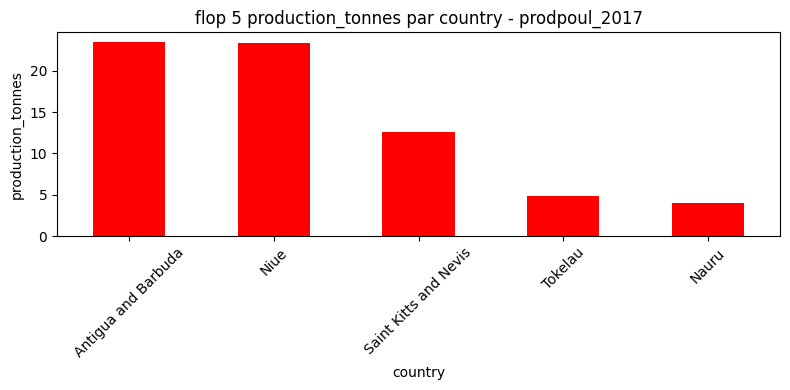

In [61]:
explore_df(prodpoul_2017, "prodpoul_2017")
top_flop(prodpoul_2017, "prodpoul_2017", valeur_col="production_tonnes", zone_col="country")


### exploration de conspoul_2017 ###

statistiques descriptives :


,pays,code_pays,Year,viande_volaille
count,222,181,222.0,222.000000
unique,222,181,NaN,NaN
top,Afghanistan,AFG,NaN,NaN
freq,1,1,NaN,NaN
mean,NaN,NaN,2017.0,20.537316
std,NaN,NaN,0.0,16.318210
min,NaN,NaN,2017.0,0.395910
25%,NaN,NaN,2017.0,6.791963
50%,NaN,NaN,2017.0,18.561650
75%,NaN,NaN,2017.0,30.444504


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


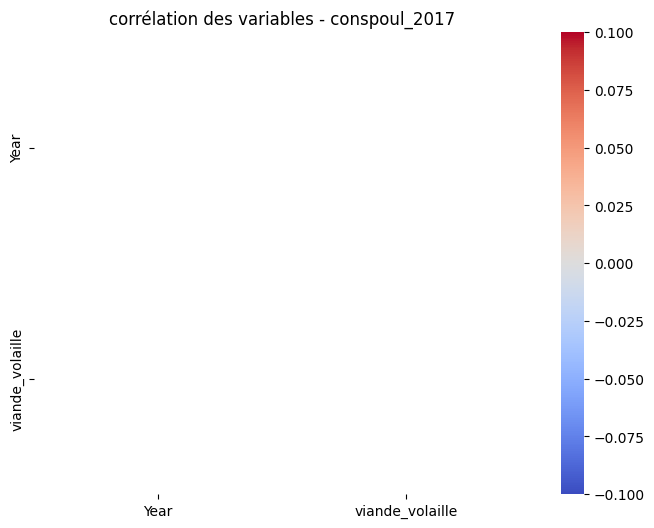

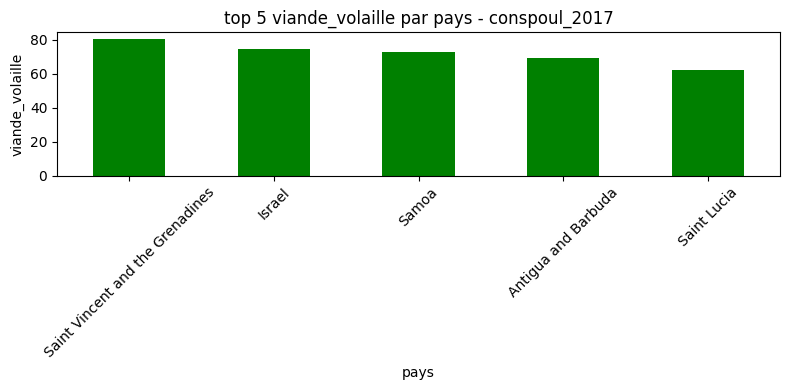

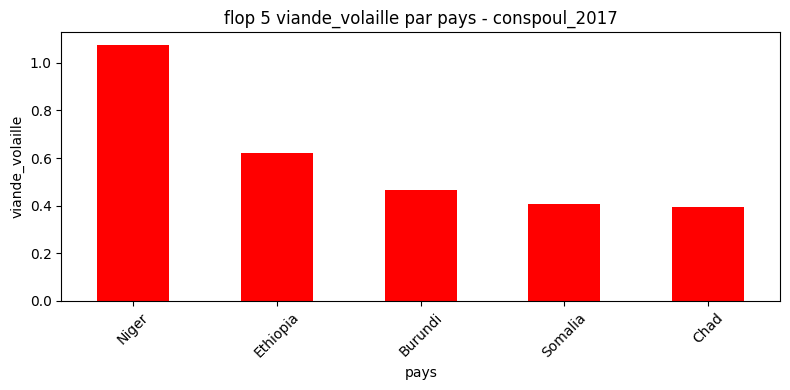

In [62]:
explore_df(conspoul_2017, "conspoul_2017")
top_flop(conspoul_2017, "conspoul_2017", valeur_col="viande_volaille", zone_col="pays")


### exploration de pib_pys_2017 ###

statistiques descriptives :


,Country Name,Country Code,Valeur
count,258,258,258.000000
unique,258,258,NaN
top,World,WLD,NaN
freq,1,1,NaN
mean,NaN,NaN,16602.181583
std,NaN,NaN,24446.064568
min,NaN,NaN,236.694473
25%,NaN,NaN,2153.334442
50%,NaN,NaN,6323.207137
75%,NaN,NaN,20845.374575


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


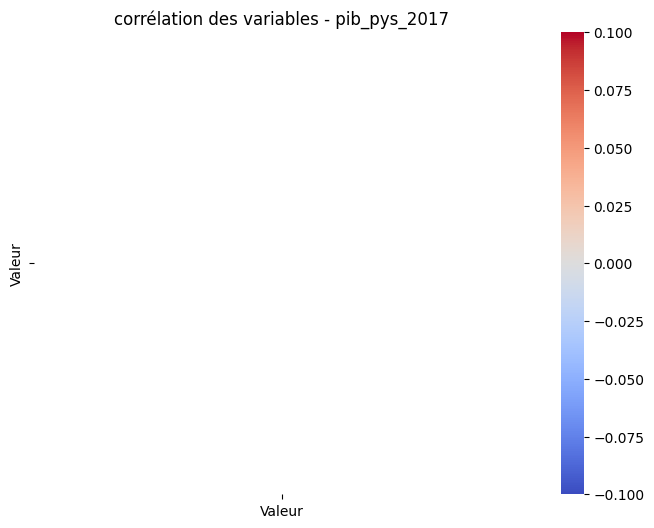

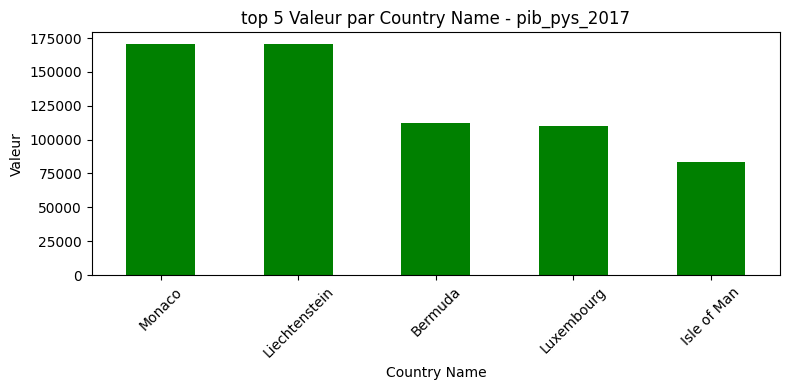

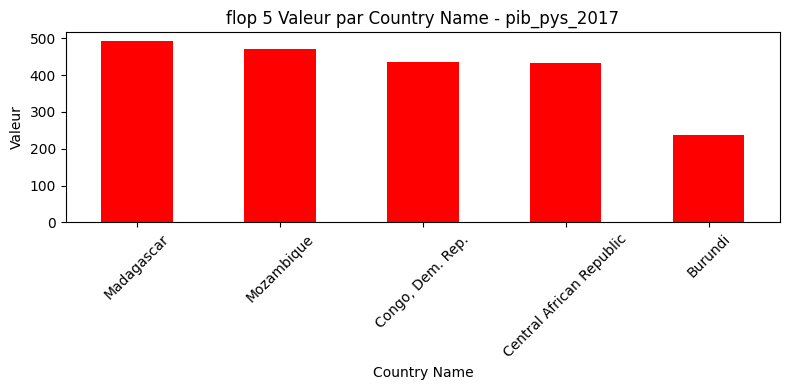

In [63]:
explore_df(pib_pys_2017, "pib_pys_2017")
top_flop(pib_pys_2017, "pib_pys_2017", valeur_col="Valeur", zone_col="Country Name")


### exploration de stab_pol_2017 ###

statistiques descriptives :


,Country,ISO3,ID Data,Year,Voice and Accountability,Political Stability,Government Effectiveness,Regulatory Quality,Rule of Law,Control of Corruption,Region
count,180,180,180.000000,180.0,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180
unique,180,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
top,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sub-Saharan Africa (SSA)
freq,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49
mean,NaN,NaN,90.500000,2017.0,46.696771,44.952381,47.427885,48.389423,46.693376,46.490664,NaN
std,NaN,NaN,52.105662,0.0,28.720866,27.474076,28.978508,29.123500,29.002791,29.257017,NaN
min,NaN,NaN,1.000000,2017.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,45.750000,2017.0,22.536946,21.785715,22.355769,23.918269,21.995193,21.514423,NaN
50%,NaN,NaN,90.500000,2017.0,45.073893,43.095238,46.875000,47.355768,44.471155,43.990385,NaN
75%,NaN,NaN,135.250000,2017.0,70.566504,66.904760,70.552883,71.754807,69.831732,70.312500,NaN


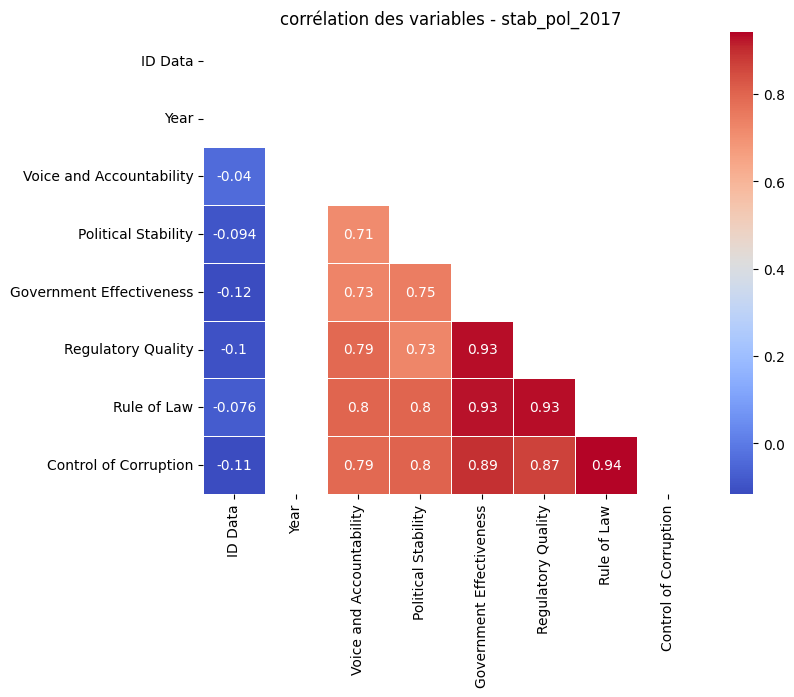

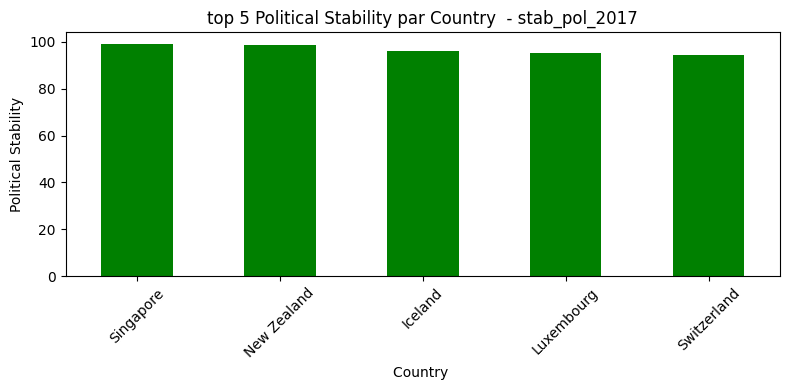

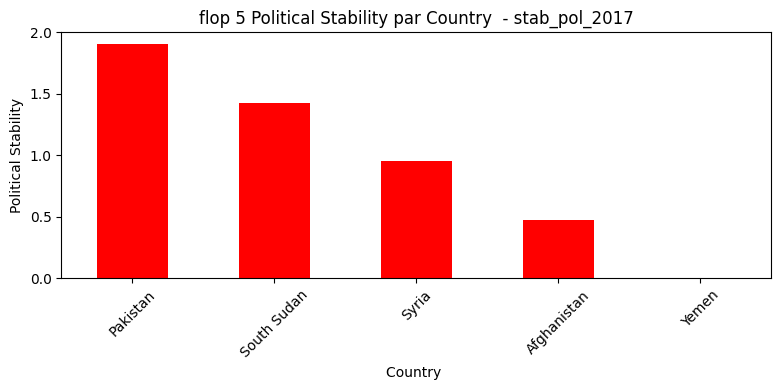

In [64]:
# Political StaB comme variable pour top/flop
explore_df(stab_pol_2017, "stab_pol_2017")
top_flop(stab_pol_2017, "stab_pol_2017", valeur_col="Political Stability", zone_col="Country ")


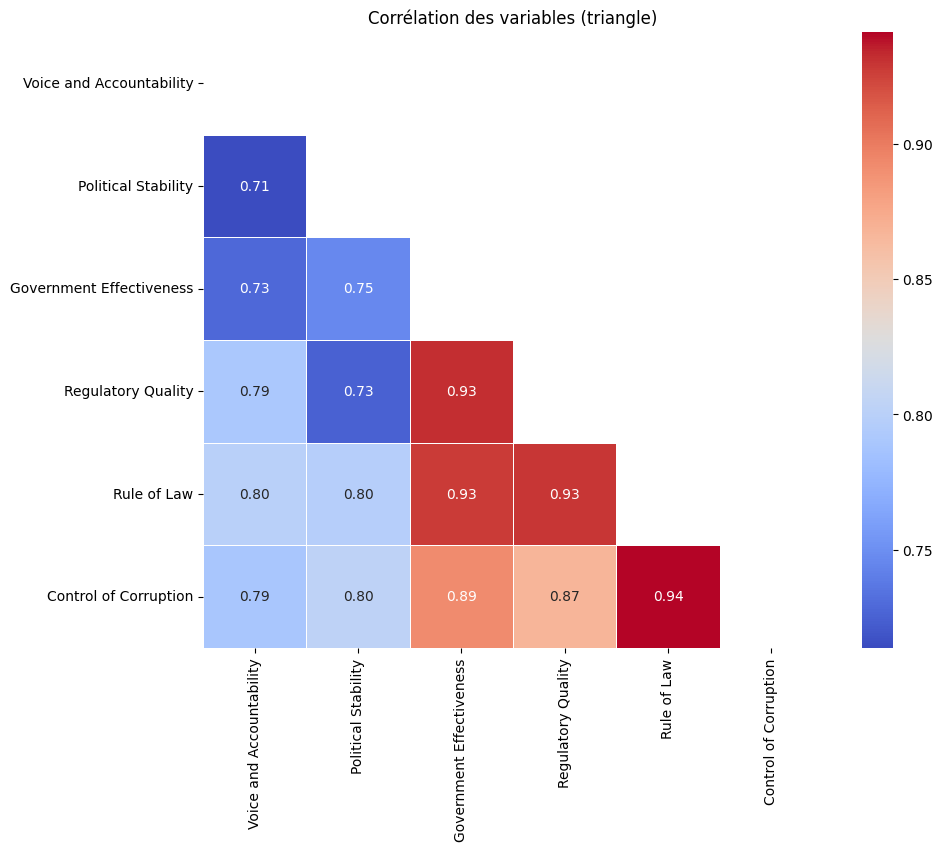

In [140]:


# Supprimer les colonnes non souhaitées
df_corr = stab_pol_2017.drop(columns=['ID Data', 'Year'], errors='ignore')

# Garder uniquement les variables numériques
df_corr = df_corr.select_dtypes(include='number')

# Matrice de corrélation
corr = df_corr.corr()

# Masque triangulaire
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Corrélation des variables (triangle)")
plt.show()


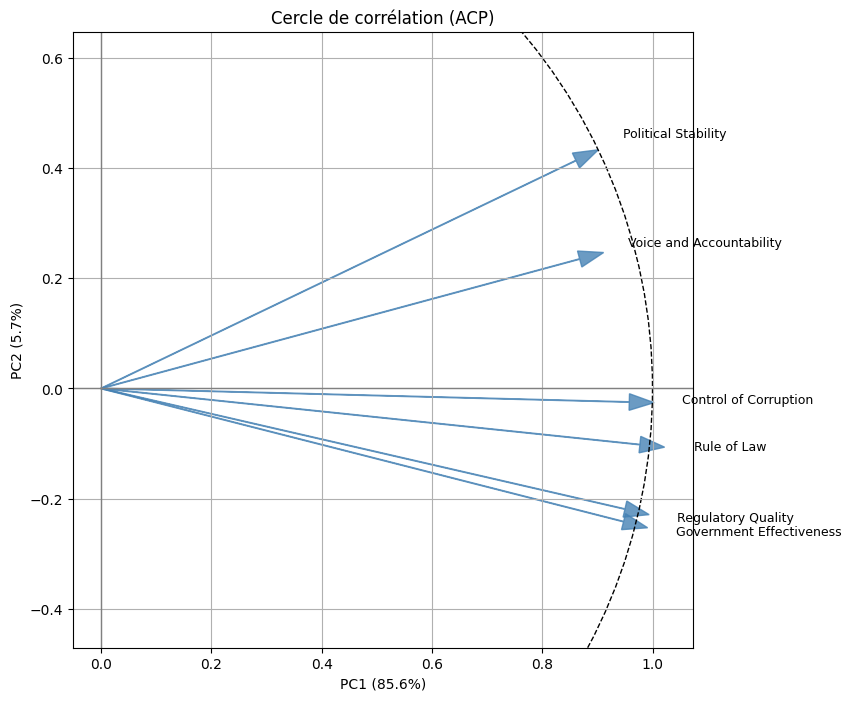

In [139]:
# 1️ Sélection des variables (sans ID Data, Year)
X = stab_pol_2017.drop(columns=['ID Data', 'Year'], errors='ignore')
X = X.select_dtypes(include='number')

# 2️ Standardisation
X_scaled = StandardScaler().fit_transform(X)

# 3️ ACP
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4️ Coordonnées des variables (loadings)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# 5️ Cercle de corrélation
plt.figure(figsize=(8, 8))
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)

for i, var in enumerate(X.columns):
    plt.arrow(
        0, 0,
        loadings[i, 0],
        loadings[i, 1],
        head_width=0.03,
        color='steelblue',
        alpha=0.8
    )
    plt.text(
        loadings[i, 0]*1.1,
        loadings[i, 1]*1.1,
        var,
        fontsize=9
    )

# Cercle unité
circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
plt.gca().add_artist(circle)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Cercle de corrélation (ACP)')
plt.axis('equal')
plt.grid(True)
plt.show()



# JOINTURE DES DFS

In [65]:
"""
dali_viande
pop_viande_ren
prodpoul_2017
conspoul_2017
pib_pys_2017
stab_pol_2017
"""

'\ndali_viande\npop_viande_ren\nprodpoul_2017\nconspoul_2017\npib_pys_2017\nstab_pol_2017\n'

In [66]:
dali_viande.columns

Index(['Code Domaine', 'Domaine', 'Code zone', 'Zone', 'Code Élément',
       'Élément', 'Code Produit', 'Produit', 'Code année', 'Année', 'Unité',
       'Valeur', 'Symbole', 'Description du Symbole'],
      dtype='object')

In [67]:
pop_2017.columns

Index(['Domaine', 'Zone', 'Produit', 'Unité', 'Valeur'], dtype='object')

In [68]:
conspoul_2017_ren = conspoul_2017.rename(columns={"viande_volaille": "viande_conso"})
prodpoul_2017_ren = prodpoul_2017.rename(columns={"production_tonnes": "production_tonnes"})
pib_pys_2017_ren = pib_pys_2017.rename(columns={"Valeur": "pib"})
stab_pol_2017_ren = stab_pol_2017.rename(columns={
    "Voice and Accountability": "Voice_Accountability",
    "Political Stability": "Political_Stability",
    "Government Effectiveness": "Gov_Effectiveness",
    "Regulatory Quality": "Reg_Quality",
    "Rule of Law": "Rule_of_Law",
    "Control of Corruption": "Control_Corruption"
})


In [69]:

# Colonnes de chaque DataFrame
print("dali_viande :", dali_viande.columns.tolist())
print("pop_2017 :", pop_2017.columns.tolist())
print("prodpoul_2017 :", prodpoul_2017.columns.tolist())
print("conspoul_2017 :", conspoul_2017.columns.tolist())
print("pib_pys_2017 :", pib_pys_2017.columns.tolist())
print("stab_pol_2017 :", stab_pol_2017.columns.tolist())


dali_viande : ['Code Domaine', 'Domaine', 'Code zone', 'Zone', 'Code Élément', 'Élément', 'Code Produit', 'Produit', 'Code année', 'Année', 'Unité', 'Valeur', 'Symbole', 'Description du Symbole']
pop_2017 : ['Domaine', 'Zone', 'Produit', 'Unité', 'Valeur']
prodpoul_2017 : ['country', 'iso3', 'production_tonnes']
conspoul_2017 : ['pays', 'code_pays', 'Year', 'viande_volaille']
pib_pys_2017 : ['Country Name', 'Country Code', 'Valeur']
stab_pol_2017 : ['Country ', 'ISO3', 'ID Data', 'Year', 'Voice and Accountability', 'Political Stability', 'Government Effectiveness', 'Regulatory Quality', 'Rule of Law', 'Control of Corruption', 'Region']


In [70]:
pop_viande_ren = pop_2017.rename(columns={"Valeur": "Valeur_pop"})

### jointure 1 dali_viande et pop_viande

j1

In [71]:
import pandas as pd


# 1️ Renommer pour éviter les doublons

dali_viande_ren = dali_viande.rename(columns={"Valeur": "Valeur_dali"})
#pop_viande_ren = pop_2017.rename(columns={"Valeur_pop": "Valeur_pop"})
prodpoul_2017_ren = prodpoul_2017.rename(columns={"production_tonnes": "production_tonnes"})
conspoul_2017_ren = conspoul_2017.rename(columns={"viande_volaille": "viande_conso"})
pib_pys_2017_ren = pib_pys_2017.rename(columns={"Valeur": "pib"})
stab_pol_2017_ren = stab_pol_2017.rename(columns={
    "Voice and Accountability": "Voice_Accountability",
    "Political Stability": "Political_Stability",
    "Government Effectiveness": "Gov_Effectiveness",
    "Regulatory Quality": "Reg_Quality",
    "Rule of Law": "Rule_of_Law",
    "Control of Corruption": "Control_Corruption",
    "Country ": "Country"
})


# 2️ Merge DALI + Pop → garder uniquement les zones communes
viande_joint = pd.merge(
    dali_viande_ren,
    pop_viande_ren [['Zone','Valeur_pop']],
    on="Zone",
    how="inner"   # inner join = seules les zones communes
)


# 3️ Merge avec conspoul → ne garder que les correspondances

merge1 = pd.merge(
    viande_joint,
    conspoul_2017_ren[['pays','viande_conso']],
    left_on="Zone",
    right_on="pays",
    how="inner"
)


# 4️ Merge avec prodpoul uniquement zones correspondantes

merge2 = pd.merge(
    merge1,
    prodpoul_2017_ren[['country','production_tonnes']],
    left_on="Zone",
    right_on="country",
    how="inner"
)


# 5️ Merge avec pib → seulement pays correspondants

merge3 = pd.merge(
    merge2,
    pib_pys_2017_ren[['Country Name','pib']],
    left_on="Zone",
    right_on="Country Name",
    how="inner"
)


# 6️ Merge avec stab_pol → seulement pays correspondants

cols_stab = ['Country','Voice_Accountability', 'Political_Stability',
             'Gov_Effectiveness','Reg_Quality', 'Rule_of_Law', 'Control_Corruption']

merge_final = pd.merge(
    merge3,
    stab_pol_2017_ren[cols_stab],
    left_on="country",
    right_on="Country",
    how="inner"
)


# 7️ Conversion en kg

def convert_to_kg(valeur, unite):
    if unite == "Milliers de tonnes":
        return valeur * 1_000_000
    if unite == "kg":
        return valeur
    # unités nutritionnelles → impossible de convertir en kg
    if unite in ["g/personne/jour", "Kcal/personne/jour"]:
        return float('nan')
    return float('nan')

# Vérifie le nom exact de la colonne Unité
if 'Unité' in merge_final.columns:
    merge_final.rename(columns={'Unité':'Unité_dali'}, inplace=True)

merge_final["Valeur_kg"] = merge_final.apply(
    lambda row: convert_to_kg(row["Valeur_pop"], row["Unité_dali"]),
    axis=1
)


# 8️ Nettoyage final

merge_final.drop_duplicates(inplace=True)
merge_final.reset_index(drop=True, inplace=True)


# 9️ Préparation pour ACP

numerical_cols = [
    'Valeur_dali', 'Valeur_pop', 'Valeur_kg', 'production_tonnes',
    'viande_conso', 'pib',
    'Voice_Accountability', 'Political_Stability', 'Gov_Effectiveness',
    'Reg_Quality', 'Rule_of_Law', 'Control_Corruption'
]

X_acp = merge_final[numerical_cols]



In [72]:
merge3.columns

Index(['Code Domaine', 'Domaine', 'Code zone', 'Zone', 'Code Élément',
       'Élément', 'Code Produit', 'Produit', 'Code année', 'Année', 'Unité',
       'Valeur_dali', 'Symbole', 'Description du Symbole', 'Valeur_pop',
       'pays', 'viande_conso', 'country', 'production_tonnes', 'Country Name',
       'pib'],
      dtype='object')

In [73]:
stab_pol_2017_ren.head()

,Country,ISO3,ID Data,Year,Voice_Accountability,Political_Stability,Gov_Effectiveness,Reg_Quality,Rule_of_Law,Control_Corruption,Region
5,Afghanistan,AFG,1,2017,22.167488,0.476190,8.173077,7.211538,5.288462,3.846154,Middle East & North Africa (MENA)
16,Albania,ALB,2,2017,54.187191,59.523811,58.653847,62.500000,39.423077,41.826923,Europe & Central Asia (ECA)
27,United Arab Emirates,ARE,3,2017,18.226601,66.666664,90.384613,80.769234,77.403847,82.692307,Middle East & North Africa (MENA)
38,Angola,AGO,4,2017,17.733990,30.476191,17.788462,13.461538,14.903846,5.769231,Sub-Saharan Africa (SSA)
49,Argentina,ARG,5,2017,64.532021,53.333332,59.134617,44.711540,46.634617,45.673077,Latin America & Carribean (LAC)


In [74]:
prodpoul_2017_ren.head()

,country,iso3,production_tonnes
56,Afghanistan,AFG,27637.84
119,Africa,NaN,6468504.50
182,Africa (FAO),NaN,6468504.50
245,Albania,ALB,14414.11
308,Algeria,DZA,400005.80


In [75]:
pib_pys_2017_ren.head()

,Country Name,Country Code,pib
0,Afghanistan,AFG,525.469771
1,Albania,ALB,4614.047969
2,Algeria,DZA,4554.667540
3,American Samoa,ASM,11863.683945
4,Andorra,AND,40672.994335


In [76]:
merge2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 585 entries, 0 to 584
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            585 non-null    object 
 1   Domaine                 585 non-null    object 
 2   Code zone               585 non-null    int64  
 3   Zone                    585 non-null    object 
 4   Code Élément            585 non-null    int64  
 5   Élément                 585 non-null    object 
 6   Code Produit            585 non-null    int64  
 7   Produit                 585 non-null    object 
 8   Code année              585 non-null    int64  
 9   Année                   585 non-null    int64  
 10  Unité                   585 non-null    object 
 11  Valeur_dali             585 non-null    float64
 12  Symbole                 585 non-null    object 
 13  Description du Symbole  585 non-null    object 
 14  Valeur_pop              585 non-null    fl

In [77]:
merge3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            560 non-null    object 
 1   Domaine                 560 non-null    object 
 2   Code zone               560 non-null    int64  
 3   Zone                    560 non-null    object 
 4   Code Élément            560 non-null    int64  
 5   Élément                 560 non-null    object 
 6   Code Produit            560 non-null    int64  
 7   Produit                 560 non-null    object 
 8   Code année              560 non-null    int64  
 9   Année                   560 non-null    int64  
 10  Unité                   560 non-null    object 
 11  Valeur_dali             560 non-null    float64
 12  Symbole                 560 non-null    object 
 13  Description du Symbole  560 non-null    object 
 14  Valeur_pop              560 non-null    fl

In [78]:

# Vérification finale
merge_final.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524 entries, 0 to 523
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            524 non-null    object 
 1   Domaine                 524 non-null    object 
 2   Code zone               524 non-null    int64  
 3   Zone                    524 non-null    object 
 4   Code Élément            524 non-null    int64  
 5   Élément                 524 non-null    object 
 6   Code Produit            524 non-null    int64  
 7   Produit                 524 non-null    object 
 8   Code année              524 non-null    int64  
 9   Année                   524 non-null    int64  
 10  Unité_dali              524 non-null    object 
 11  Valeur_dali             524 non-null    float64
 12  Symbole                 524 non-null    object 
 13  Description du Symbole  524 non-null    object 
 14  Valeur_pop              524 non-null    fl

In [79]:
# Nombre de zones uniques
nb_zones_uniques = merge_final['Zone'].nunique()
print("Nombre de zones uniques dans merge_final :", nb_zones_uniques)

# Pour voir la liste des zones uniques
zones_uniques = merge_final['Zone'].unique()
print("Zones uniques :", zones_uniques)


Nombre de zones uniques dans merge_final : 43
Zones uniques : ['Afghanistan' 'Angola' 'Bangladesh' 'Botswana' 'Burkina Faso' 'Canada'
 'Costa Rica' 'Cuba' 'El Salvador' 'Eswatini' 'France' 'Gabon' 'Ghana'
 'Guatemala' 'Guyana' 'Honduras' 'Iraq' 'Kazakhstan' 'Kenya' 'Lesotho'
 'Luxembourg' 'Madagascar' 'Malawi' 'Mali' 'Mozambique' 'Myanmar'
 'Nicaragua' 'Niger' 'Oman' 'Pakistan' 'Panama' 'Paraguay' 'Philippines'
 'Portugal' 'Rwanda' 'Sierra Leone' 'Sri Lanka' 'Suriname' 'Togo'
 'Ukraine' 'Uruguay' 'Vanuatu' 'Zimbabwe']


In [80]:
viande_joint.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur_dali,Symbole,Description du Symbole,Valeur_pop
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2734,Viande de Volailles,2017,2017,Milliers de tonnes,28.0,S,Données standardisées,36296.113
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2734,Viande de Volailles,2017,2017,Milliers de tonnes,29.0,S,Données standardisées,36296.113
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2734,Viande de Volailles,2017,2017,Milliers de tonnes,0.0,S,Données standardisées,36296.113
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2734,Viande de Volailles,2017,2017,Milliers de tonnes,57.0,S,Données standardisées,36296.113
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5123,Pertes,2734,Viande de Volailles,2017,2017,Milliers de tonnes,2.0,S,Données standardisées,36296.113


In [81]:
conspoul_2017_ren.head()

,pays,code_pays,Year,viande_conso
56,Afghanistan,AFG,2017,1.787717
118,Africa,NaN,2017,6.213189
180,Africa (FAO),NaN,2017,6.310000
242,Albania,ALB,2017,11.474741
304,Algeria,DZA,2017,6.857851


In [82]:
#print(viande_joint["Zone"].unique())
#print(conspoul_2017_ren["code_pays"].unique())


In [83]:
#viande_joint["ISO3"] = viande_joint["Zone"].apply(to_iso3)

#viande_joint[viande_joint["ISO3"].isna()]["Zone"].unique()


j2

In [84]:
prodpoul_2017_ren.head()

,country,iso3,production_tonnes
56,Afghanistan,AFG,27637.84
119,Africa,NaN,6468504.50
182,Africa (FAO),NaN,6468504.50
245,Albania,ALB,14414.11
308,Algeria,DZA,400005.80


In [85]:
merge1.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur_dali,Symbole,Description du Symbole,Valeur_pop,pays,viande_conso
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2734,Viande de Volailles,2017,2017,Milliers de tonnes,28.0,S,Données standardisées,36296.113,Afghanistan,1.787717
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2734,Viande de Volailles,2017,2017,Milliers de tonnes,29.0,S,Données standardisées,36296.113,Afghanistan,1.787717
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2734,Viande de Volailles,2017,2017,Milliers de tonnes,0.0,S,Données standardisées,36296.113,Afghanistan,1.787717
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2734,Viande de Volailles,2017,2017,Milliers de tonnes,57.0,S,Données standardisées,36296.113,Afghanistan,1.787717
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5123,Pertes,2734,Viande de Volailles,2017,2017,Milliers de tonnes,2.0,S,Données standardisées,36296.113,Afghanistan,1.787717


j3

In [86]:
dali_viande_ren.reset_index(drop=True, inplace=True)
dali_viande_ren

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur_dali,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2734,Viande de Volailles,2017,2017,Milliers de tonnes,28.00,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2734,Viande de Volailles,2017,2017,Milliers de tonnes,29.00,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2734,Viande de Volailles,2017,2017,Milliers de tonnes,0.00,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2734,Viande de Volailles,2017,2017,Milliers de tonnes,57.00,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5123,Pertes,2734,Viande de Volailles,2017,2017,Milliers de tonnes,2.00,S,Données standardisées
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2056,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,5142,Nourriture,2734,Viande de Volailles,2017,2017,Milliers de tonnes,67.00,S,Données standardisées
2057,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,645,Disponibilité alimentaire en quantité (kg/pers...,2734,Viande de Volailles,2017,2017,kg,4.68,Fc,Donnée calculée
2058,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,664,Disponibilité alimentaire (Kcal/personne/jour),2734,Viande de Volailles,2017,2017,Kcal/personne/jour,16.00,Fc,Donnée calculée
2059,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,674,Disponibilité de protéines en quantité (g/pers...,2734,Viande de Volailles,2017,2017,g/personne/jour,1.59,Fc,Donnée calculée


In [87]:
pop.reset_index(drop=True, inplace=True)
pop

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN
3,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23680.871,X,Sources internationales sûres,NaN
4,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24726.684,X,Sources internationales sûres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4406,OA,Séries temporelles annuelles,181,Zimbabwe,511,Population totale,3010,Population-Estimations,2014,2014,1000 personnes,13586.707,X,Sources internationales sûres,NaN
4407,OA,Séries temporelles annuelles,181,Zimbabwe,511,Population totale,3010,Population-Estimations,2015,2015,1000 personnes,13814.629,X,Sources internationales sûres,NaN
4408,OA,Séries temporelles annuelles,181,Zimbabwe,511,Population totale,3010,Population-Estimations,2016,2016,1000 personnes,14030.331,X,Sources internationales sûres,NaN
4409,OA,Séries temporelles annuelles,181,Zimbabwe,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,14236.595,X,Sources internationales sûres,NaN


In [88]:
prodpoul_2017_ren.reset_index(drop=True, inplace=True)
prodpoul_2017_ren

,country,iso3,production_tonnes
0,Afghanistan,AFG,2.763784e+04
1,Africa,NaN,6.468504e+06
2,Africa (FAO),NaN,6.468504e+06
3,Albania,ALB,1.441411e+04
4,Algeria,DZA,4.000058e+05
...,...,...,...
234,Western Europe (FAO),NaN,5.060576e+06
235,World,OWID_WRL,1.248002e+08
236,Yemen,YEM,1.686283e+05
237,Zambia,ZMB,4.742058e+04


In [89]:
prodpoul_2017_ren.reset_index(drop=True, inplace=True)
prodpoul_2017_ren

,country,iso3,production_tonnes
0,Afghanistan,AFG,2.763784e+04
1,Africa,NaN,6.468504e+06
2,Africa (FAO),NaN,6.468504e+06
3,Albania,ALB,1.441411e+04
4,Algeria,DZA,4.000058e+05
...,...,...,...
234,Western Europe (FAO),NaN,5.060576e+06
235,World,OWID_WRL,1.248002e+08
236,Yemen,YEM,1.686283e+05
237,Zambia,ZMB,4.742058e+04


In [90]:
conspoul_2017_ren.reset_index(drop=True, inplace=True)
conspoul_2017_ren

,pays,code_pays,Year,viande_conso
0,Afghanistan,AFG,2017,1.787717
1,Africa,NaN,2017,6.213189
2,Africa (FAO),NaN,2017,6.310000
3,Albania,ALB,2017,11.474741
4,Algeria,DZA,2017,6.857851
...,...,...,...,...
217,Western Europe (FAO),NaN,2017,20.020000
218,World,OWID_WRL,2017,15.241873
219,Yemen,YEM,2017,7.633187
220,Zambia,ZMB,2017,3.461330


In [91]:
stab_pol_2017_ren

,Country,ISO3,ID Data,Year,Voice_Accountability,Political_Stability,Gov_Effectiveness,Reg_Quality,Rule_of_Law,Control_Corruption,Region
5,Afghanistan,AFG,1,2017,22.167488,0.476190,8.173077,7.211538,5.288462,3.846154,Middle East & North Africa (MENA)
16,Albania,ALB,2,2017,54.187191,59.523811,58.653847,62.500000,39.423077,41.826923,Europe & Central Asia (ECA)
27,United Arab Emirates,ARE,3,2017,18.226601,66.666664,90.384613,80.769234,77.403847,82.692307,Middle East & North Africa (MENA)
38,Angola,AGO,4,2017,17.733990,30.476191,17.788462,13.461538,14.903846,5.769231,Sub-Saharan Africa (SSA)
49,Argentina,ARG,5,2017,64.532021,53.333332,59.134617,44.711540,46.634617,45.673077,Latin America & Carribean (LAC)
...,...,...,...,...,...,...,...,...,...,...,...
1930,Venezuela,VEN,176,2017,14.285714,10.000000,7.211538,2.403846,0.480769,6.730769,Latin America & Carribean (LAC)
1941,Vietnam,VNM,177,2017,10.344828,54.761906,53.846153,35.576923,55.288460,31.250000,East Asia & Pacific (EAP)
1952,Syria,SYR,178,2017,1.970443,0.952381,2.884615,3.365385,0.961538,2.403846,Middle East & North Africa (MENA)
1963,Zambia,ZMB,179,2017,36.453201,52.380951,25.961538,33.173077,41.346153,35.096153,Sub-Saharan Africa (SSA)


In [92]:
pib_pys_2017_ren.reset_index(drop=True, inplace=True)
pib_pys_2017_ren

,Country Name,Country Code,pib
0,Afghanistan,AFG,525.469771
1,Albania,ALB,4614.047969
2,Algeria,DZA,4554.667540
3,American Samoa,ASM,11863.683945
4,Andorra,AND,40672.994335
...,...,...,...
253,Sub-Saharan Africa,SSF,1542.244649
254,Sub-Saharan Africa (excluding high income),SSA,1630.625959
255,Sub-Saharan Africa (IDA & IBRD countries),TSS,1542.244649
256,Upper middle income,UMC,8053.633182


In [93]:
merge2.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur_dali,Symbole,Description du Symbole,Valeur_pop,pays,viande_conso,country,production_tonnes
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2734,Viande de Volailles,2017,2017,Milliers de tonnes,28.0,S,Données standardisées,36296.113,Afghanistan,1.787717,Afghanistan,27637.84
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2734,Viande de Volailles,2017,2017,Milliers de tonnes,29.0,S,Données standardisées,36296.113,Afghanistan,1.787717,Afghanistan,27637.84
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2734,Viande de Volailles,2017,2017,Milliers de tonnes,0.0,S,Données standardisées,36296.113,Afghanistan,1.787717,Afghanistan,27637.84
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2734,Viande de Volailles,2017,2017,Milliers de tonnes,57.0,S,Données standardisées,36296.113,Afghanistan,1.787717,Afghanistan,27637.84
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5123,Pertes,2734,Viande de Volailles,2017,2017,Milliers de tonnes,2.0,S,Données standardisées,36296.113,Afghanistan,1.787717,Afghanistan,27637.84


In [94]:
pib_pys_2017_ren.head()

,Country Name,Country Code,pib
0,Afghanistan,AFG,525.469771
1,Albania,ALB,4614.047969
2,Algeria,DZA,4554.667540
3,American Samoa,ASM,11863.683945
4,Andorra,AND,40672.994335


In [95]:
merge3.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            560 non-null    object 
 1   Domaine                 560 non-null    object 
 2   Code zone               560 non-null    int64  
 3   Zone                    560 non-null    object 
 4   Code Élément            560 non-null    int64  
 5   Élément                 560 non-null    object 
 6   Code Produit            560 non-null    int64  
 7   Produit                 560 non-null    object 
 8   Code année              560 non-null    int64  
 9   Année                   560 non-null    int64  
 10  Unité                   560 non-null    object 
 11  Valeur_dali             560 non-null    float64
 12  Symbole                 560 non-null    object 
 13  Description du Symbole  560 non-null    object 
 14  Valeur_pop              560 non-null    fl

In [96]:
stab_pol_2017_ren.head()


,Country,ISO3,ID Data,Year,Voice_Accountability,Political_Stability,Gov_Effectiveness,Reg_Quality,Rule_of_Law,Control_Corruption,Region
5,Afghanistan,AFG,1,2017,22.167488,0.476190,8.173077,7.211538,5.288462,3.846154,Middle East & North Africa (MENA)
16,Albania,ALB,2,2017,54.187191,59.523811,58.653847,62.500000,39.423077,41.826923,Europe & Central Asia (ECA)
27,United Arab Emirates,ARE,3,2017,18.226601,66.666664,90.384613,80.769234,77.403847,82.692307,Middle East & North Africa (MENA)
38,Angola,AGO,4,2017,17.733990,30.476191,17.788462,13.461538,14.903846,5.769231,Sub-Saharan Africa (SSA)
49,Argentina,ARG,5,2017,64.532021,53.333332,59.134617,44.711540,46.634617,45.673077,Latin America & Carribean (LAC)


In [97]:
merge_final.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,...,Country Name,pib,Country,Voice_Accountability,Political_Stability,Gov_Effectiveness,Reg_Quality,Rule_of_Law,Control_Corruption,Valeur_kg
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2734,Viande de Volailles,2017,2017,...,Afghanistan,525.469771,Afghanistan,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2734,Viande de Volailles,2017,2017,...,Afghanistan,525.469771,Afghanistan,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2734,Viande de Volailles,2017,2017,...,Afghanistan,525.469771,Afghanistan,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2734,Viande de Volailles,2017,2017,...,Afghanistan,525.469771,Afghanistan,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5123,Pertes,2734,Viande de Volailles,2017,2017,...,Afghanistan,525.469771,Afghanistan,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10


In [98]:
merge_final.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,...,Country Name,pib,Country,Voice_Accountability,Political_Stability,Gov_Effectiveness,Reg_Quality,Rule_of_Law,Control_Corruption,Valeur_kg
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2734,Viande de Volailles,2017,2017,...,Afghanistan,525.469771,Afghanistan,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2734,Viande de Volailles,2017,2017,...,Afghanistan,525.469771,Afghanistan,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2734,Viande de Volailles,2017,2017,...,Afghanistan,525.469771,Afghanistan,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2734,Viande de Volailles,2017,2017,...,Afghanistan,525.469771,Afghanistan,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5123,Pertes,2734,Viande de Volailles,2017,2017,...,Afghanistan,525.469771,Afghanistan,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10


# ACP POUR SELECTION DE VARIABLES PERTINANTES

In [99]:
merge_final.select_dtypes(include=[np.number]).columns


Index(['Code zone', 'Code Élément', 'Code Produit', 'Code année', 'Année',
       'Valeur_dali', 'Valeur_pop', 'viande_conso', 'production_tonnes', 'pib',
       'Voice_Accountability', 'Political_Stability', 'Gov_Effectiveness',
       'Reg_Quality', 'Rule_of_Law', 'Control_Corruption', 'Valeur_kg'],
      dtype='object')

In [100]:
# Colonnes que l'on souhaite utiliser pour l'ACP
cols_acp = [
    'Valeur_dali', 'Valeur_pop', 'viande_conso',
    'production_tonnes', 'pib',
    'Voice_Accountability', 'Political_Stability', 'Gov_Effectiveness',
    'Reg_Quality', 'Rule_of_Law', 'Control_Corruption', 'Valeur_kg'
]

# Vérifier que toutes les colonnes existent dans merge_final
cols_acp_exist = [col for col in cols_acp if col in merge_final.columns]

# Sélection des colonnes numériques pour l'ACP
X = merge_final[cols_acp_exist].copy()

# Vérification
print("Colonnes utilisées pour l'ACP :", cols_acp_exist)
X.info()


Colonnes utilisées pour l'ACP : ['Valeur_dali', 'Valeur_pop', 'viande_conso', 'production_tonnes', 'pib', 'Voice_Accountability', 'Political_Stability', 'Gov_Effectiveness', 'Reg_Quality', 'Rule_of_Law', 'Control_Corruption', 'Valeur_kg']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524 entries, 0 to 523
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Valeur_dali           524 non-null    float64
 1   Valeur_pop            524 non-null    float64
 2   viande_conso          524 non-null    float64
 3   production_tonnes     524 non-null    float64
 4   pib                   524 non-null    float64
 5   Voice_Accountability  524 non-null    float64
 6   Political_Stability   524 non-null    float64
 7   Gov_Effectiveness     524 non-null    float64
 8   Reg_Quality           524 non-null    float64
 9   Rule_of_Law           524 non-null    float64
 10  Control_Corruption    524 non-null    f

In [101]:

X_clean = X.fillna(X.mean())
X_clean


,Valeur_dali,Valeur_pop,viande_conso,production_tonnes,pib,Voice_Accountability,Political_Stability,Gov_Effectiveness,Reg_Quality,Rule_of_Law,Control_Corruption,Valeur_kg
0,28.00,36296.113,1.787717,27637.84,525.469771,22.167488,0.476190,8.173077,7.211538,5.288462,3.846154,3.629611e+10
1,29.00,36296.113,1.787717,27637.84,525.469771,22.167488,0.476190,8.173077,7.211538,5.288462,3.846154,3.629611e+10
2,0.00,36296.113,1.787717,27637.84,525.469771,22.167488,0.476190,8.173077,7.211538,5.288462,3.846154,3.629611e+10
3,57.00,36296.113,1.787717,27637.84,525.469771,22.167488,0.476190,8.173077,7.211538,5.288462,3.846154,3.629611e+10
4,2.00,36296.113,1.787717,27637.84,525.469771,22.167488,0.476190,8.173077,7.211538,5.288462,3.846154,3.629611e+10
...,...,...,...,...,...,...,...,...,...,...,...,...
519,67.00,14236.595,5.068907,92300.32,3448.086991,14.778325,20.952381,9.134615,4.326923,7.211538,9.615385,1.423660e+10
520,4.68,14236.595,5.068907,92300.32,3448.086991,14.778325,20.952381,9.134615,4.326923,7.211538,9.615385,1.423659e+04
521,16.00,14236.595,5.068907,92300.32,3448.086991,14.778325,20.952381,9.134615,4.326923,7.211538,9.615385,2.526427e+10
522,1.59,14236.595,5.068907,92300.32,3448.086991,14.778325,20.952381,9.134615,4.326923,7.211538,9.615385,2.526427e+10


In [102]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)


In [103]:

pca = PCA()
pca.fit(X_scaled)


PCA()

In [104]:

variance_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Variance_expliquee": pca.explained_variance_ratio_,
    "Variance_cumulee": np.cumsum(pca.explained_variance_ratio_)
})

variance_df


,PC,Variance_expliquee,Variance_cumulee
0,PC1,0.477805,0.477805
1,PC2,0.218345,0.696150
2,PC3,0.090368,0.786518
3,PC4,0.055677,0.842195
4,PC5,0.039702,0.881897
5,PC6,0.035343,0.917240
6,PC7,0.030104,0.947344
7,PC8,0.021030,0.968374
8,PC9,0.012772,0.981146
9,PC10,0.008530,0.989676


In [105]:
#importance = loadings.iloc[:, :5].abs().sum(axis=1)
#variables_importantes = importance.sort_values(ascending=False)
#variables_importantes


In [106]:
%whos



Variable                     Type              Data/Info
--------------------------------------------------------
GradientBoostingClassifier   ABCMeta           <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
GridSearchCV                 ABCMeta           <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
IsolationForest              ABCMeta           <class 'sklearn.ensemble.<...>iforest.IsolationForest'>
KMeans                       ABCMeta           <class 'sklearn.cluster._kmeans.KMeans'>
KNeighborsClassifier         ABCMeta           <class 'sklearn.neighbors<...>on.KNeighborsClassifier'>
LabelEncoder                 type              <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
LogisticRegression           type              <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
PCA                          ABCMeta           <class 'sklearn.decomposition._pca.PCA'>
RandomForestClassifier       ABCMeta           <class 'sklearn.ensemble.<...>.RandomForestCl

In [107]:
# Création des loadings depuis le PCA sklearn
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=cols_acp   # ou X.columns si les colonnes sont identiques
)

# Maintenant ton code fonctionne
var_coords = loadings.iloc[:, :5].values
kmeans = KMeans(n_clusters=3, random_state=42).fit(var_coords)
clusters = kmeans.labels_

clusters


array([2, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [108]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=cols_acp   # ou X.columns
)


In [109]:
var_coords = loadings.iloc[:, :5].values


In [110]:
var_coords = loadings.iloc[:, :5].values
kmeans = KMeans(n_clusters=3, random_state=42).fit(var_coords)
clusters = kmeans.labels_
clusters


array([2, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

### variables les plus importantes

In [111]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# Colonnes à utiliser pour l'ACP
cols_acp = [
    'Valeur_dali', 'Valeur_pop', 'Year_x', 'viande_conso',
    'production_tonnes', 'pib', 'ID Data', 'Year_y',
    'Voice_Accountability', 'Political_Stability', 'Gov_Effectiveness',
    'Reg_Quality', 'Rule_of_Law', 'Control_Corruption', 'Valeur_kg'
]

# 🔹 Vérifier que les colonnes existent réellement dans merge_final
cols_acp_exist = [col for col in cols_acp if col in merge_final.columns]

# Préparation du DataFrame pour l'ACP
X = merge_final[cols_acp_exist].copy()

# Remplacer les NaN par la moyenne des colonnes numériques
X = X.fillna(X.mean(numeric_only=True))

# Standardisation
X_scaled = StandardScaler().fit_transform(X)

# ACP
pca = PCA()
pca.fit(X_scaled)

# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(X_scaled.shape[1])],
    index=cols_acp_exist
)

# Importance globale sur les 5 premiers axes
importance = loadings.iloc[:, :5].abs().sum(axis=1)
variables_importantes = importance.sort_values(ascending=False)

# Affichage
variables_importantes


,0
Valeur_dali,1.737139
viande_conso,1.443216
pib,1.405275
production_tonnes,1.324927
Valeur_pop,1.129741
Valeur_kg,1.023610
Control_Corruption,0.868371
Rule_of_Law,0.806377
Reg_Quality,0.705957
Gov_Effectiveness,0.668421


### cercle de coorelation

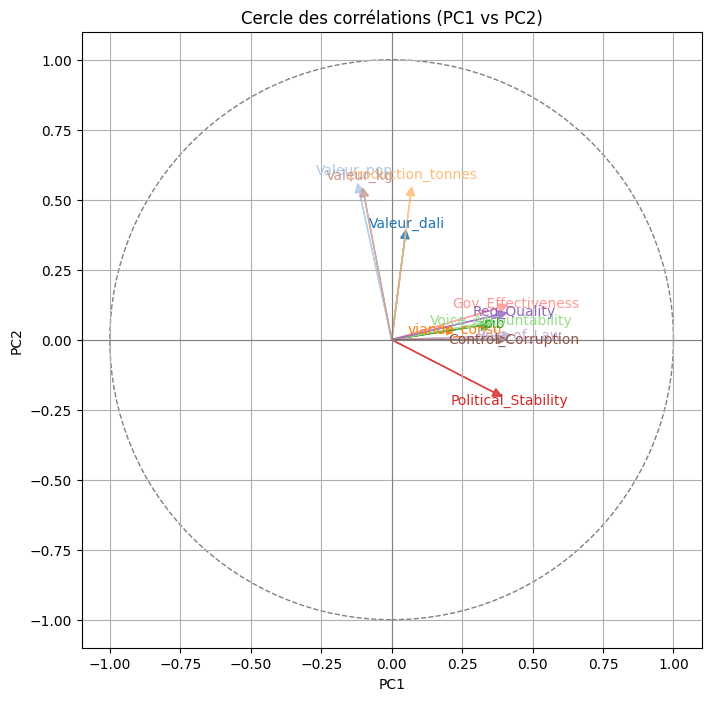

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
pcs = ['PC1','PC2']

# Cercle
circle = plt.Circle((0,0),1, color='grey', fill=False, linestyle='--')
plt.gca().add_artist(circle)

# Flèches pour chaque variable
colors = plt.cm.tab20.colors  # palette de 20 couleurs
for i, col in enumerate(cols_acp_exist):  # <- utiliser uniquement les colonnes existantes
    plt.arrow(0, 0, loadings.loc[col, pcs[0]], loadings.loc[col, pcs[1]],
              color=colors[i % len(colors)], alpha=0.8, head_width=0.03, head_length=0.03)
    plt.text(loadings.loc[col, pcs[0]]*1.15, loadings.loc[col, pcs[1]]*1.15,
             col, color=colors[i % len(colors)], ha='center', va='center', fontsize=10)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Cercle des corrélations (PC1 vs PC2)')
plt.grid(True)
plt.axhline(0, color='grey', linewidth=0.8)
plt.axvline(0, color='grey', linewidth=0.8)
plt.show()


### biplot

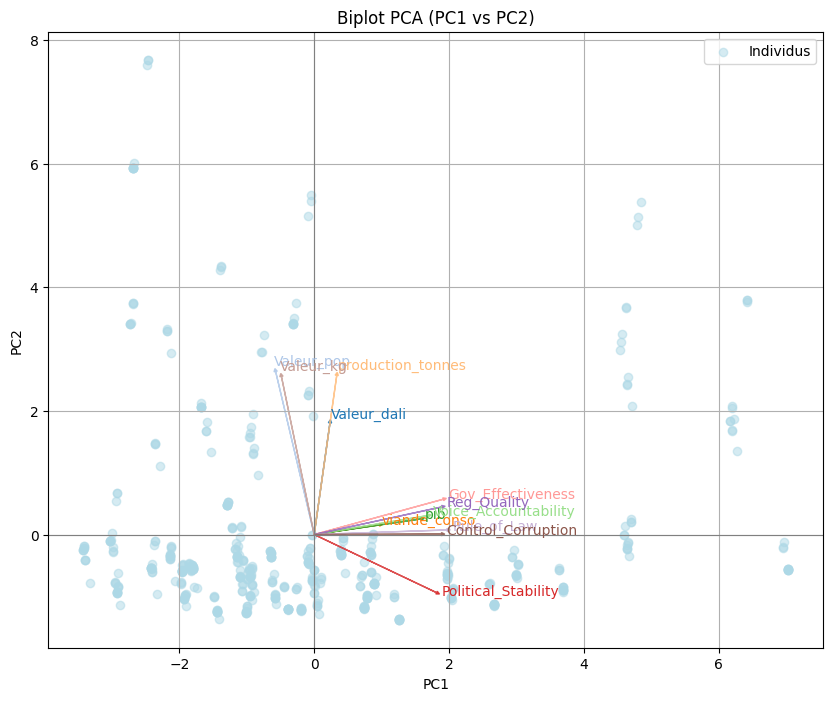

In [113]:
import matplotlib.pyplot as plt

# Scores des individus
scores = pd.DataFrame(
    pca.transform(X_scaled),
    columns=[f"PC{i+1}" for i in range(X_scaled.shape[1])]
)

plt.figure(figsize=(10,8))
plt.scatter(scores['PC1'], scores['PC2'], alpha=0.5, color='lightblue', label='Individus')

# Flèches pour les variables (uniquement celles utilisées dans l'ACP)
colors = plt.cm.tab20.colors
for i, col in enumerate(cols_acp_exist):  # <- utiliser cols_acp_exist
    plt.arrow(0, 0, loadings.loc[col,'PC1']*5, loadings.loc[col,'PC2']*5,
              color=colors[i % len(colors)], alpha=0.8, head_width=0.05, head_length=0.05)
    plt.text(loadings.loc[col,'PC1']*5.2, loadings.loc[col,'PC2']*5.2,
             col, color=colors[i % len(colors)], fontsize=10)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Biplot PCA (PC1 vs PC2)')
plt.grid(True)
plt.axhline(0, color='grey', linewidth=0.8)
plt.axvline(0, color='grey', linewidth=0.8)
plt.legend()
plt.show()


In [114]:
from sklearn.cluster import KMeans

# On utilise les 5 premières composantes pour clusterer les variables
var_coords = loadings.iloc[:, :5].values  # shape = (n_variables, 5)
kmeans = KMeans(n_clusters=3, random_state=42).fit(var_coords)
clusters = kmeans.labels_

# Ajouter les clusters au dataframe des loadings
loadings['cluster'] = clusters

print(loadings[['cluster']])


                      cluster
Valeur_dali                 2
Valeur_pop                  1
viande_conso                1
production_tonnes           1
pib                         0
Voice_Accountability        1
Political_Stability         1
Gov_Effectiveness           1
Reg_Quality                 1
Rule_of_Law                 1
Control_Corruption          1
Valeur_kg                   1


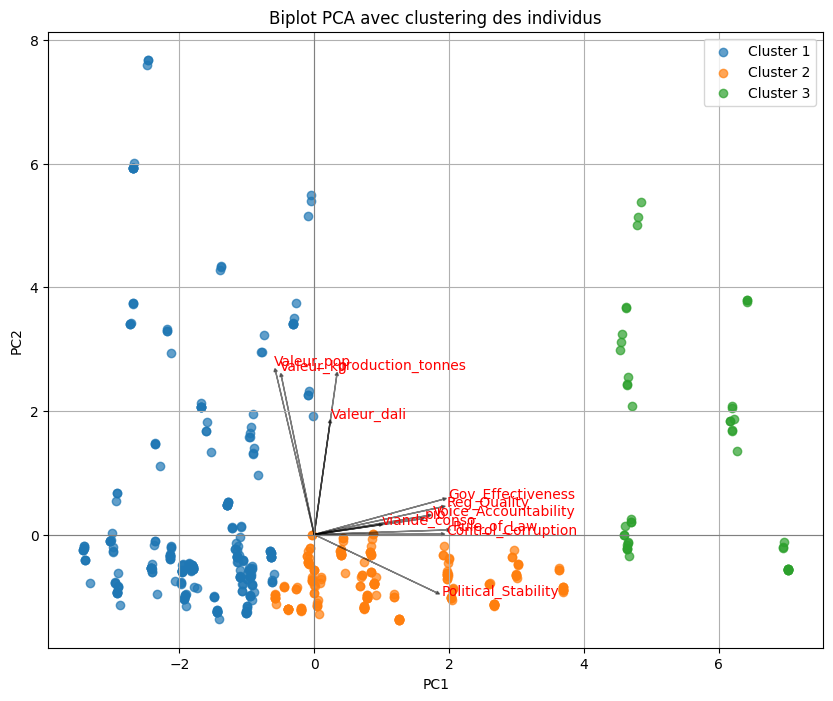

In [115]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Scores sur PC1 et PC2
scores_2D = scores[['PC1','PC2']].copy()

# Clustering (3 clusters)
kmeans_ind = KMeans(n_clusters=3, random_state=42)
scores_2D['cluster'] = kmeans_ind.fit_predict(scores_2D)

# Biplot avec couleurs par cluster
plt.figure(figsize=(10,8))
for c in range(3):
    plt.scatter(
        scores_2D[scores_2D['cluster']==c]['PC1'],
        scores_2D[scores_2D['cluster']==c]['PC2'],
        label=f'Cluster {c+1}', alpha=0.7
    )

# Flèches des variables (cols réellement utilisées)
for i, col in enumerate(cols_acp_exist):
    plt.arrow(0, 0, loadings.loc[col,'PC1']*5, loadings.loc[col,'PC2']*5,
              color='black', alpha=0.5, head_width=0.05, head_length=0.05)
    plt.text(loadings.loc[col,'PC1']*5.2, loadings.loc[col,'PC2']*5.2,
             col, color='red', fontsize=10)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Biplot PCA avec clustering des individus')
plt.axhline(0, color='grey', linewidth=0.8)
plt.axvline(0, color='grey', linewidth=0.8)
plt.grid(True)
plt.legend()
plt.show()


In [116]:
from sklearn.cluster import KMeans

# Scores sur PC1 et PC2
scores_2D = scores[['PC1','PC2']]

# Clustering en 3 groupes
kmeans_ind = KMeans(n_clusters=3, random_state=42)
scores_2D['cluster'] = kmeans_ind.fit_predict(scores_2D)


/tmp/ipython-input-1540565624.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scores_2D['cluster'] = kmeans_ind.fit_predict(scores_2D)


In [117]:
cols_acp_subset = X.columns.tolist()

In [118]:
# Vérification qu'elles existent dans les loadings
cols_acp_exist = [col for col in cols_acp_subset if col in loadings.index]
cols_acp_exist

['Valeur_dali',
 'Valeur_pop',
 'viande_conso',
 'production_tonnes',
 'pib',
 'Voice_Accountability',
 'Political_Stability',
 'Gov_Effectiveness',
 'Reg_Quality',
 'Rule_of_Law',
 'Control_Corruption',
 'Valeur_kg']

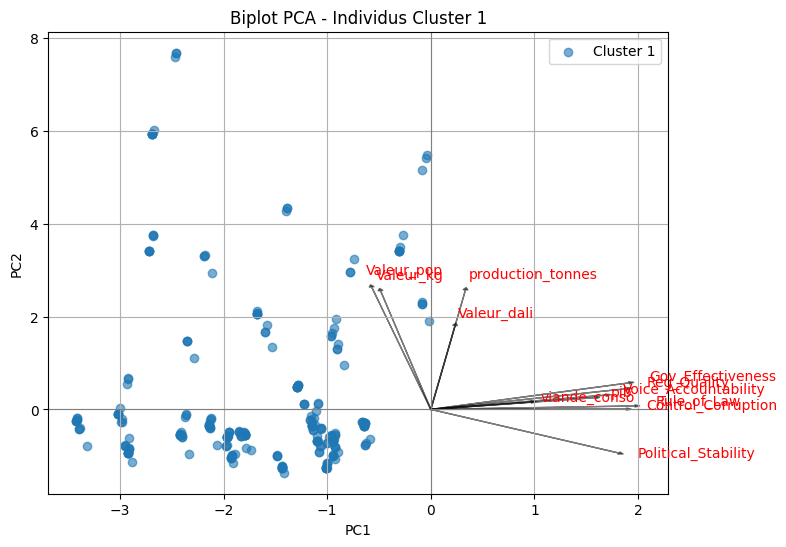

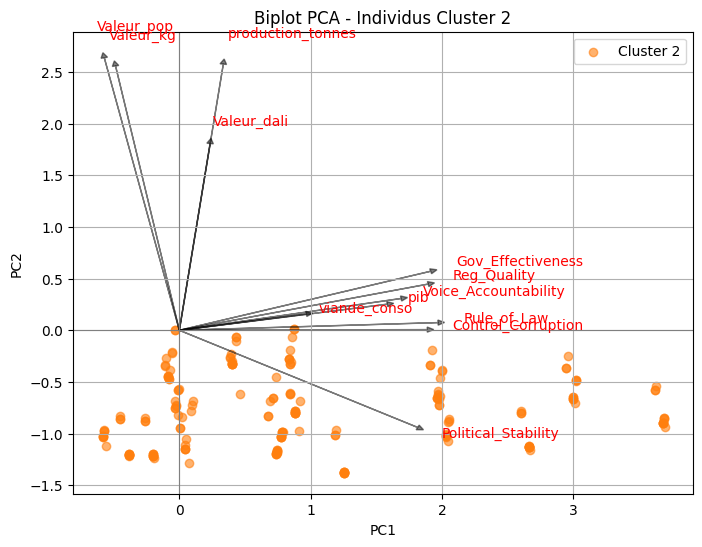

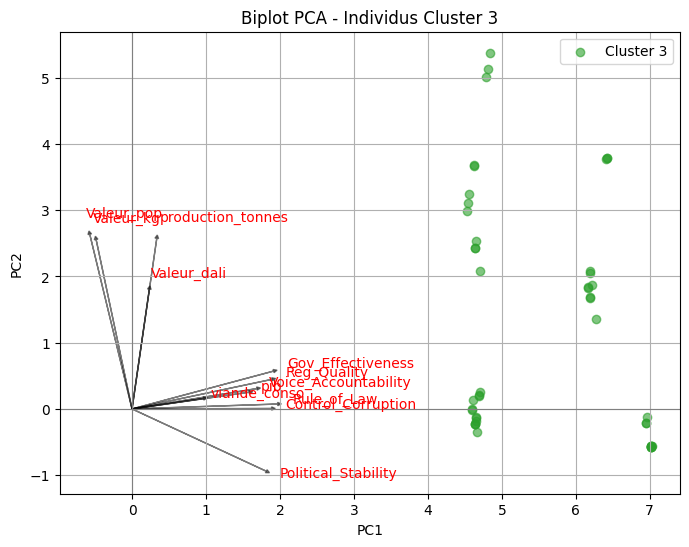

In [119]:
import matplotlib.pyplot as plt

# Colonnes réellement utilisées dans l'ACP et présentes dans loadings
cols_acp_subset_exist = [col for col in cols_acp_subset if col in loadings.index]

# Échelle pour les flèches
arrow_scale = 5

# Biplots par cluster
for c in range(3):
    plt.figure(figsize=(8,6))
    cluster_data = scores_2D[scores_2D['cluster'] == c]

    # Points pour les individus
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'], alpha=0.6, color=f"C{c}", label=f'Cluster {c+1}')

    # Flèches variables
    for i, col in enumerate(cols_acp_subset_exist):
        plt.arrow(0, 0, loadings.loc[col,'PC1']*arrow_scale, loadings.loc[col,'PC2']*arrow_scale,
                  color='black', alpha=0.5, head_width=0.05, head_length=0.05)
        plt.text(loadings.loc[col,'PC1']*arrow_scale*1.1, loadings.loc[col,'PC2']*arrow_scale*1.1,
                 col, color='red', fontsize=10)

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'Biplot PCA - Individus Cluster {c+1}')
    plt.axhline(0, color='grey', linewidth=0.8)
    plt.axvline(0, color='grey', linewidth=0.8)
    plt.grid(True)
    plt.legend()
    plt.show()


### METHODE DU COUDE AVEC 3 cluster differents

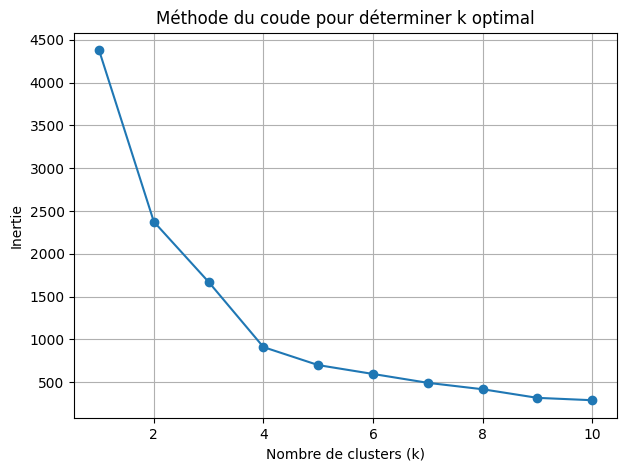

In [120]:


inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scores_2D[['PC1','PC2']])
    inertias.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du coude pour déterminer k optimal')
plt.grid(True)
plt.show()


/tmp/ipython-input-2736021147.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scores_2D[f'cluster_{k}'] = km.fit_predict(scores_2D[['PC1','PC2']])
/tmp/ipython-input-2736021147.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scores_2D[f'cluster_{k}'] = km.fit_predict(scores_2D[['PC1','PC2']])
/tmp/ipython-input-2736021147.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

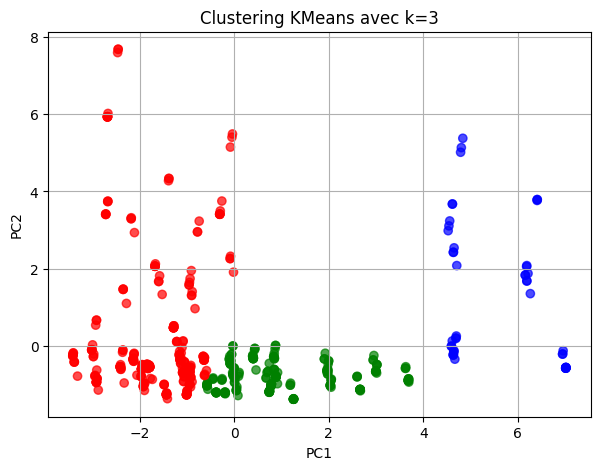

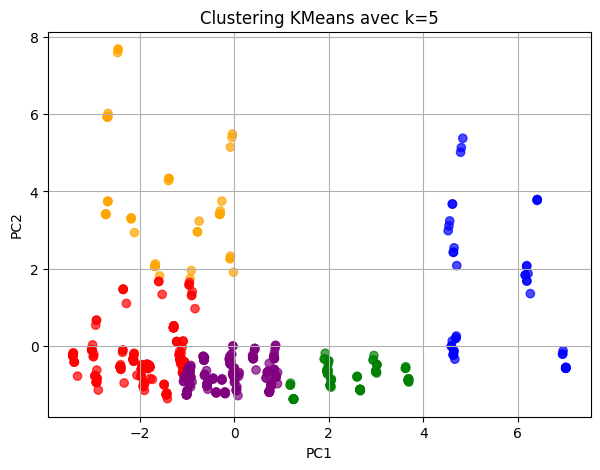

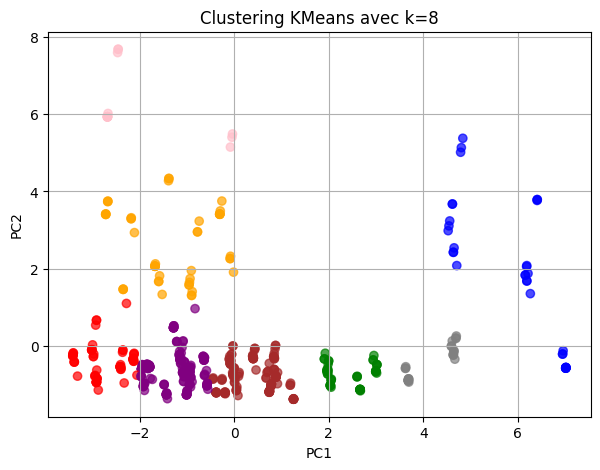

In [121]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# ---- 1. Clustering ----
k_values = [3, 5, 8]
colors = {0:"red", 1:"green", 2:"blue", 3:"orange", 4:"purple", 5:"brown", 6:"pink", 7:"grey"}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    scores_2D[f'cluster_{k}'] = km.fit_predict(scores_2D[['PC1','PC2']])

# ---- 2. Visualisation ----
for k in k_values:
    plt.figure(figsize=(7,5))
    plt.scatter(
        scores_2D['PC1'],
        scores_2D['PC2'],
        c=scores_2D[f'cluster_{k}'].map(colors),
        alpha=0.7
    )
    plt.title(f'Clustering KMeans avec k={k}')
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()



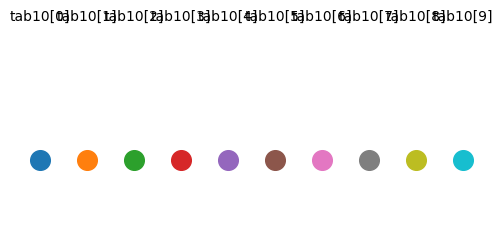

In [122]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,2))
for i in range(10):
    plt.scatter(i, 0, color=plt.cm.tab10(i), s=200)
    plt.text(i, 0.1, f"tab10[{i}]", ha='center')
plt.axis('off')
plt.show()


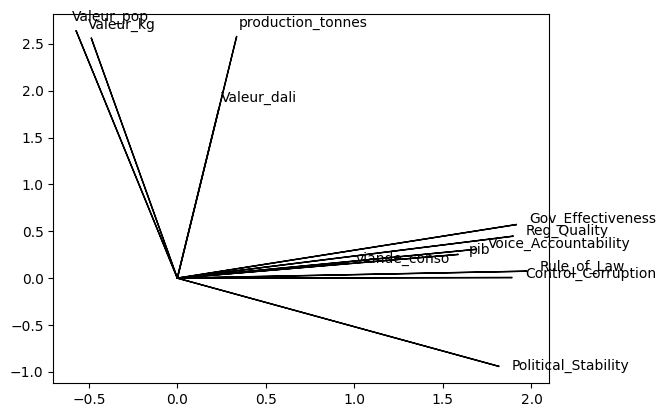

In [123]:
for i, col in enumerate(cols_acp_exist):
    plt.arrow(0, 0, loadings.loc[col,'PC1']*5, loadings.loc[col,'PC2']*5)
    plt.text(loadings.loc[col,'PC1']*5.2, loadings.loc[col,'PC2']*5.2, col)


In [124]:
merge_final.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,...,Country Name,pib,Country,Voice_Accountability,Political_Stability,Gov_Effectiveness,Reg_Quality,Rule_of_Law,Control_Corruption,Valeur_kg
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2734,Viande de Volailles,2017,2017,...,Afghanistan,525.469771,Afghanistan,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2734,Viande de Volailles,2017,2017,...,Afghanistan,525.469771,Afghanistan,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2734,Viande de Volailles,2017,2017,...,Afghanistan,525.469771,Afghanistan,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2734,Viande de Volailles,2017,2017,...,Afghanistan,525.469771,Afghanistan,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5123,Pertes,2734,Viande de Volailles,2017,2017,...,Afghanistan,525.469771,Afghanistan,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10


In [125]:
merge_final.columns

Index(['Code Domaine', 'Domaine', 'Code zone', 'Zone', 'Code Élément',
       'Élément', 'Code Produit', 'Produit', 'Code année', 'Année',
       'Unité_dali', 'Valeur_dali', 'Symbole', 'Description du Symbole',
       'Valeur_pop', 'pays', 'viande_conso', 'country', 'production_tonnes',
       'Country Name', 'pib', 'Country', 'Voice_Accountability',
       'Political_Stability', 'Gov_Effectiveness', 'Reg_Quality',
       'Rule_of_Law', 'Control_Corruption', 'Valeur_kg'],
      dtype='object')

In [126]:
colonnes_a_supprimer = ["Code Domaine", "Code zone", "Code année", "Année", "Country Name", "Code Produit","Country","Zone","Unité_dali", "Symbole","pays","Domaine","Produit"]#, "Produit","Unité_dali","pays","",""]
merge_final = merge_final.drop(columns=[c for c in colonnes_a_supprimer if c in merge_final.columns])
merge_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524 entries, 0 to 523
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Élément            524 non-null    int64  
 1   Élément                 524 non-null    object 
 2   Valeur_dali             524 non-null    float64
 3   Description du Symbole  524 non-null    object 
 4   Valeur_pop              524 non-null    float64
 5   viande_conso            524 non-null    float64
 6   country                 524 non-null    object 
 7   production_tonnes       524 non-null    float64
 8   pib                     524 non-null    float64
 9   Voice_Accountability    524 non-null    float64
 10  Political_Stability     524 non-null    float64
 11  Gov_Effectiveness       524 non-null    float64
 12  Reg_Quality             524 non-null    float64
 13  Rule_of_Law             524 non-null    float64
 14  Control_Corruption      524 non-null    fl

In [127]:
display(merge_final.head())


,Code Élément,Élément,Valeur_dali,Description du Symbole,Valeur_pop,viande_conso,country,production_tonnes,pib,Voice_Accountability,Political_Stability,Gov_Effectiveness,Reg_Quality,Rule_of_Law,Control_Corruption,Valeur_kg
0,5511,Production,28.0,Données standardisées,36296.113,1.787717,Afghanistan,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
1,5611,Importations - Quantité,29.0,Données standardisées,36296.113,1.787717,Afghanistan,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
2,5072,Variation de stock,0.0,Données standardisées,36296.113,1.787717,Afghanistan,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
3,5301,Disponibilité intérieure,57.0,Données standardisées,36296.113,1.787717,Afghanistan,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
4,5123,Pertes,2.0,Données standardisées,36296.113,1.787717,Afghanistan,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10


In [128]:
#conspoul_2017.columns
#prodpoul_2017.columns
#pib_pys_2017.columns
#stab_pol_2017.columns

In [129]:


# colonnes numériques
#numeric_df = merge_final.select_dtypes(include=np.number)

# matrice de corrélation
#corr = numeric_df.corr()

#  masque pour le triangle supérieur
#mask = np.triu(np.ones_like(corr, dtype=bool))

# heatmap
#plt.figure(figsize=(12,10))
#sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", linewidths=0.5)
#plt.title("Heatmap de corrélation (triangle inférieur) - merge_final")
#plt.show()


In [130]:
merge_final.isna().sum()


,0
Code Élément,0
Élément,0
Valeur_dali,0
Description du Symbole,0
Valeur_pop,0
viande_conso,0
country,0
production_tonnes,0
pib,0
Voice_Accountability,0


In [131]:
#merge_final = merge_final.loc[:, ~merge_final.columns.duplicated()]


In [132]:
# Supprimer les colonnes aux positions 6 et 9
#merge_final.drop(merge_final.columns[[6, 9]], axis=1, inplace=True)


In [133]:
# Pourcentage de valeurs nulles par colonne
(merge_final.isna().sum() / len(merge_final)) * 100


,0
Code Élément,0.000000
Élément,0.000000
Valeur_dali,0.000000
Description du Symbole,0.000000
Valeur_pop,0.000000
viande_conso,0.000000
country,0.000000
production_tonnes,0.000000
pib,0.000000
Voice_Accountability,0.000000


In [134]:
df_num = merge_final.select_dtypes(include=['float64', 'int64'])
df_num.head()


,Code Élément,Valeur_dali,Valeur_pop,viande_conso,production_tonnes,pib,Voice_Accountability,Political_Stability,Gov_Effectiveness,Reg_Quality,Rule_of_Law,Control_Corruption,Valeur_kg
0,5511,28.0,36296.113,1.787717,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
1,5611,29.0,36296.113,1.787717,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
2,5072,0.0,36296.113,1.787717,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
3,5301,57.0,36296.113,1.787717,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10
4,5123,2.0,36296.113,1.787717,27637.84,525.469771,22.167488,0.47619,8.173077,7.211538,5.288462,3.846154,3.629611e+10


In [135]:
merge_final.info()
merge_final.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524 entries, 0 to 523
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Élément            524 non-null    int64  
 1   Élément                 524 non-null    object 
 2   Valeur_dali             524 non-null    float64
 3   Description du Symbole  524 non-null    object 
 4   Valeur_pop              524 non-null    float64
 5   viande_conso            524 non-null    float64
 6   country                 524 non-null    object 
 7   production_tonnes       524 non-null    float64
 8   pib                     524 non-null    float64
 9   Voice_Accountability    524 non-null    float64
 10  Political_Stability     524 non-null    float64
 11  Gov_Effectiveness       524 non-null    float64
 12  Reg_Quality             524 non-null    float64
 13  Rule_of_Law             524 non-null    float64
 14  Control_Corruption      524 non-null    fl

,0
Code Élément,0
Élément,0
Valeur_dali,0
Description du Symbole,0
Valeur_pop,0
viande_conso,0
country,0
production_tonnes,0
pib,0
Voice_Accountability,0


#nettoyage df final

In [136]:
for col in merge_final.columns:
    print(col)


Code Élément
Élément
Valeur_dali
Description du Symbole
Valeur_pop
viande_conso
country
production_tonnes
pib
Voice_Accountability
Political_Stability
Gov_Effectiveness
Reg_Quality
Rule_of_Law
Control_Corruption
Valeur_kg
